In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import os
import numpy as np
from matplotlib import pyplot as plt
import camb
from camb import model, initialpower
from camb import sources

print('Using CAMB %s installed at %s' % (camb.__version__, os.path.dirname(camb.__file__)))
# make sure the version and path is what you expect

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb}'


Using CAMB 1.6.5 installed at /Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/camb


In [2]:
from camb import sources

pars = camb.CAMBparams()
pars.set_cosmology(H0=67.8, ombh2=0.0222, omch2=0.119, mnu=0.06, omk=0, tau=0.0952)  #flat ACDM-nu cosmology
pars.InitPower.set_params(As=2.21e-9, ns=0.961)

# galaxy source window 
# Gaussian window centered at z=0.7 as an approximation for the 
# DES main galaxy sample, applying linear bias b=1.22.
b = 1.15

pars.SourceWindows = [
    sources.GaussianSourceWindow(source_type='counts', bias=b, redshift=0.7, sigma=0.15)
]

#we want CMB lensing
pars.Want_CMB_lensing = True
pars.set_for_lmax(2000, lens_potential_accuracy=1)

#results
results = camb.get_results(pars)

# extract spectra disctionary (window x power ...)
# raw_cl=True ensures we get the pure spectra without any L(L+1)/2pi scaling applied by default
cls = results.get_source_cls_dict(raw_cl=True)

# Create an array for the multipoles (ell)
l_max = 2000
ls = np.arange(l_max + 1)

#Galaxy-Galaxy auto-spectrum (Window 1 x Window 1)
cl_gg = cls['W1xW1'][:l_max+1]
print(cl_gg)
# Galaxy - Lensing Potential cross-spectrum 
cl_g_phi = cls['W1xP'][:l_max+1]

# 6. Convert the Lensing Potential to Lensing Convergence (kappa)
# We multiply by l(l+1)/2 to get the galaxy-convergence cross-spectrum
scaling_factor = (ls * (ls + 1)) / 2.0
cl_k_g = scaling_factor * cl_g_phi


[0.00000000e+00 0.00000000e+00 3.81227860e-06 ... 4.69152150e-08
 4.68892751e-08 4.68633610e-08]


[           nan            nan 3.50347255e-01 ... 5.77717128e+02
 5.78128822e+02 5.78540564e+02]


/var/folders/_n/vm9nc6_54_1_2m60q4p1xhww0000gn/T/ipykernel_86530/2832510736.py:43: RuntimeWarning: invalid value encountered in divide
  snr_l_sq_th = (2*ls+1)*(cl_k_g**2) / ((cl_k_g**2) + (cl_k_k) * (cl_gg))


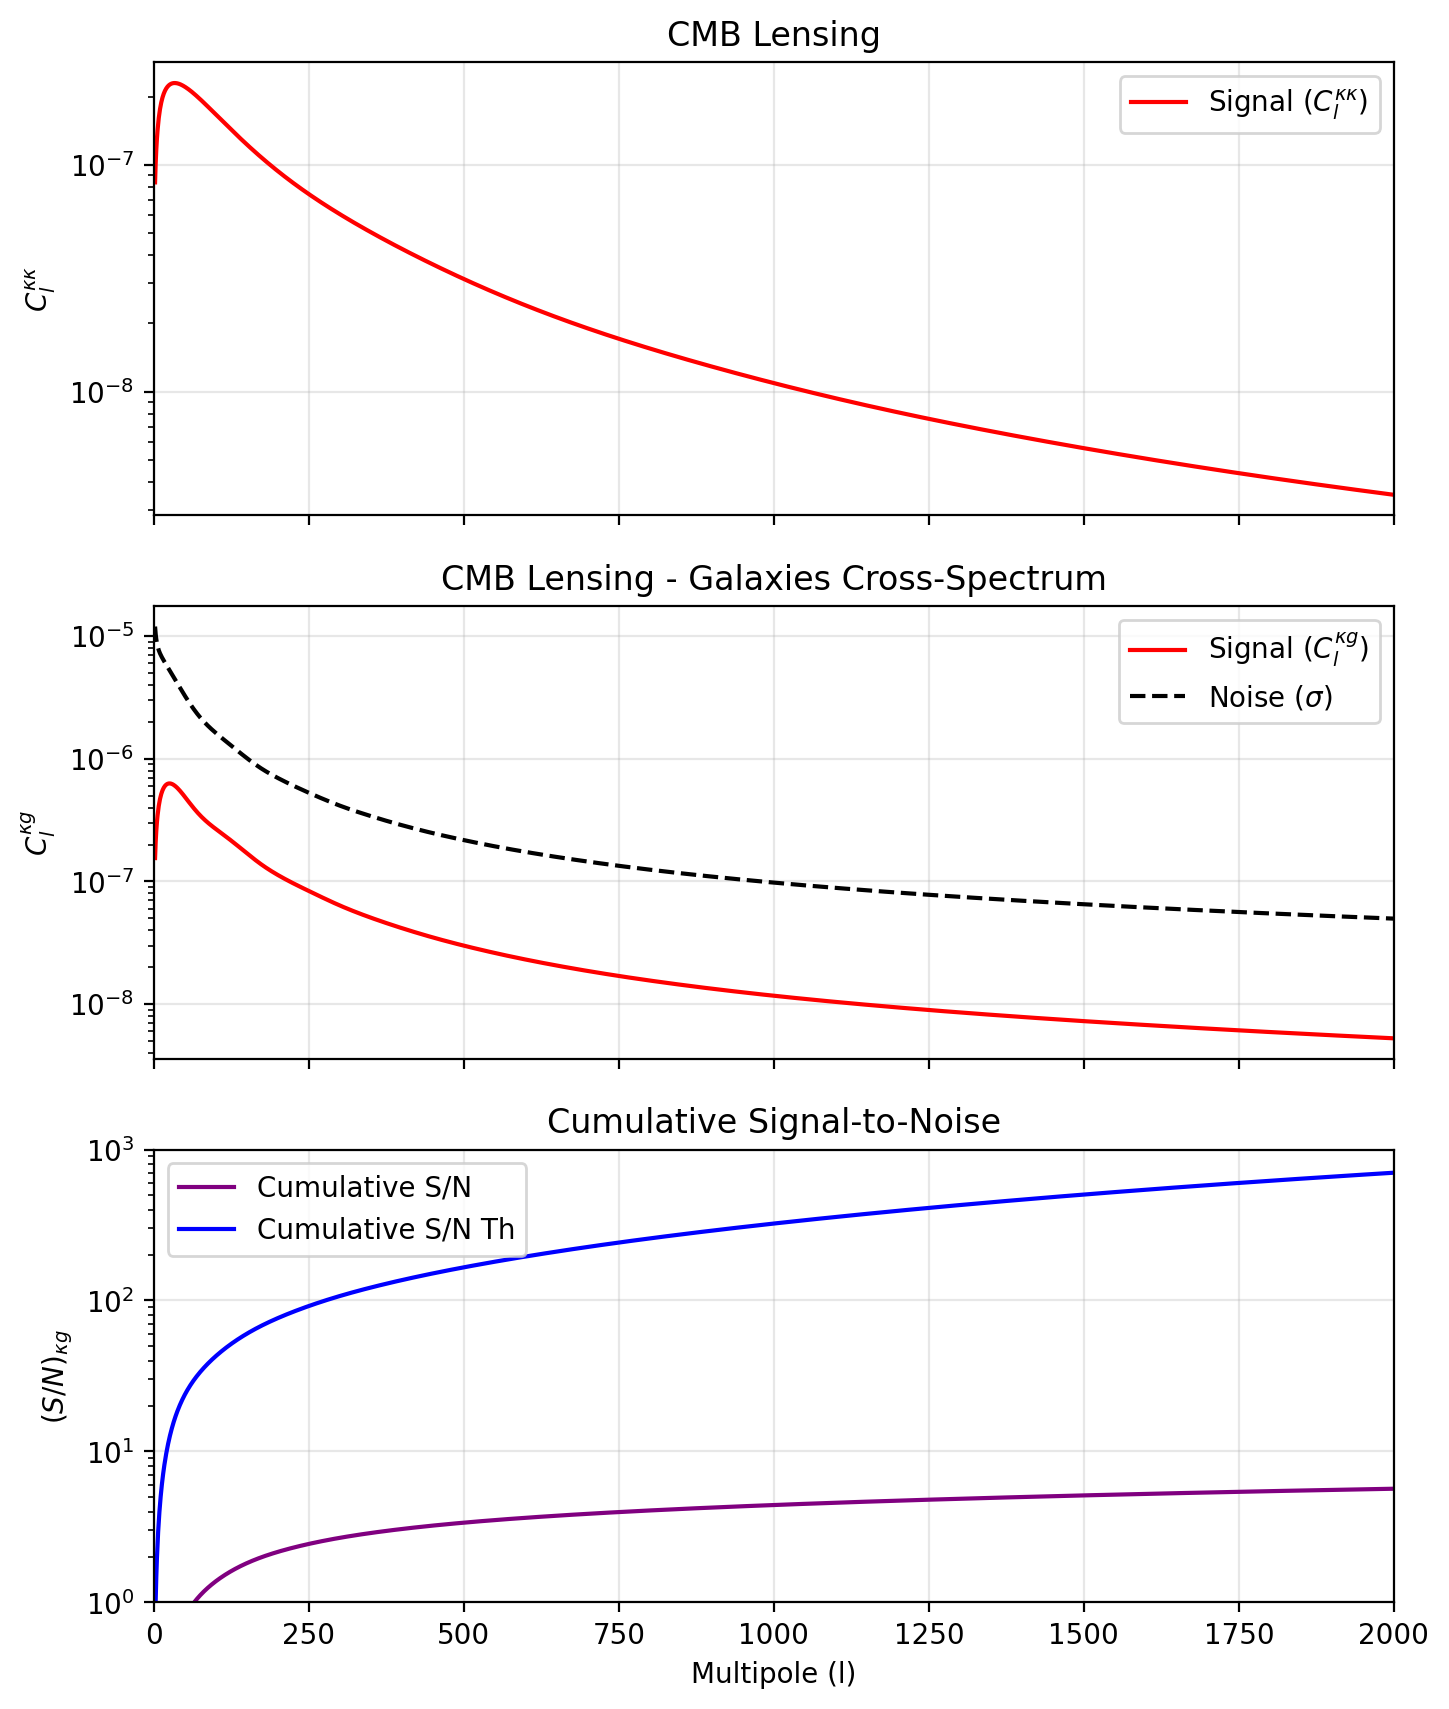

In [3]:
import matplotlib.pyplot as plt

# --- 1. Constants and Survey Specifications ---
# DES-SV sky fraction: 131 square degrees out of the full sky (41253 sq deg)
f_sky = 131.0 / 41253.0 

# Galaxy density: 5.39 galaxies per sq arcmin converted to steradians^-1
n_arcmin = 5.39
n_sr = n_arcmin * (60.0 * 180.0 / np.pi)**2
N_gg = 1.0 / n_sr  # Constant shot noise N_l^{gg}

# --- 2. Extract CMB Lensing Auto-Spectrum ---
# Extract Lensing Potential auto-spectrum (PxP)
cl_phi_phi = cls['PxP'][:l_max+1]

# Convert Potential to Convergence auto-spectrum (kappa-kappa)
# Formula: C_l^{kappa kappa} = [l(l+1)/2]^2 * C_l^{phi phi}
cl_k_k = (scaling_factor**2) * cl_phi_phi

# --- 3. Mock CMB Lensing Noise (N_l^{kappa kappa}) ---
# We approximate the noise curve to mimic the SPT/Planck behavior shown in Fig 1.
N_kk = 5e-7 * np.ones_like(ls)

# --- 4. Calculate Theoretical Noise per Multipole (Equation 15) ---
# We compute this only for l >= 2 to avoid division by zero
sigma_C_kg = np.zeros_like(ls, dtype=float)
for l in range(2, l_max + 1):
    variance = (cl_k_g[l]**2) + (cl_k_k[l] + N_kk[l]) * (cl_gg[l] + N_gg)
    sigma_C_kg[l] = np.sqrt(variance / (f_sky * (2 * l + 1)))

# --- 5. Calculate Cumulative SNR (Equation 16) ---
cumulative_snr = np.zeros_like(ls, dtype=float)
snr_squared_sum = 0.0

#for l in range(2, l_max + 1):
    # SNR^2 for a single multipole
    #snr_l_sq = (cl_k_g[l]**2) / ((cl_k_g[l]**2) + (cl_k_k[l] + N_kk[l]) * (cl_gg[l] + N_gg))
    #snr_squared_sum += (2 * l + 1) * snr_l_sq
    #cumulative_snr[l] = (f_sky * snr_squared_sum)

snr_l_sq = f_sky*(2*ls+1)*(cl_k_g**2) / ((cl_k_g**2) + (cl_k_k + N_kk) * (cl_gg + N_gg))
cumulative_snr = np.sqrt(np.cumsum(snr_l_sq[2:]))
snr_l_sq_th = (2*ls+1)*(cl_k_g**2) / ((cl_k_g**2) + (cl_k_k) * (cl_gg))
print(snr_l_sq_th)
cumulative_snr_th = np.sqrt(np.cumsum(snr_l_sq_th[2:]))


#plot figure 1

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 10), sharex=True)


# Up: auto power spectrum of lensing potential only
ax1.plot(ls[2:], cl_k_k[2:], color='red', label=r'Signal ($C_l^{\kappa \kappa}$)')
#ax1.plot(ls[2:], sigma_C_kg[2:], color='black', linestyle='--', label=r'Noise ($\sigma$)')
ax1.set_yscale('log')
ax1.set_ylabel(r'$C_l^{\kappa \kappa}$')
ax1.set_title('CMB Lensing')
ax1.legend()
ax1.grid(True, alpha=0.3)


# Mid: Cross-spectrum and its noise
ax2.plot(ls[2:], cl_k_g[2:], color='red', label=r'Signal ($C_l^{\kappa g}$)')
ax2.plot(ls[2:], sigma_C_kg[2:], color='black', linestyle='--', label=r'Noise ($\sigma$)')
ax2.set_yscale('log')
ax2.set_ylabel(r'$C_l^{\kappa g}$')
ax2.set_title('CMB Lensing - Galaxies Cross-Spectrum')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom: Cumulative SNR
ax3.plot(ls[2:], cumulative_snr, color='purple', label='Cumulative S/N')
ax3.plot(ls[2:], cumulative_snr_th, color='blue', label='Cumulative S/N Th')

ax3.set_yscale('log')
ax3.set_ylabel(r'$(S/N)_{\kappa g}$')
ax3.set_xlabel('Multipole (l)')
ax3.set_title('Cumulative Signal-to-Noise')
ax3.set_xlim(0, 2000)
ax3.set_ylim(1, 1000) # Adjust based on expected DES-SV SNR (~5-8)
ax3.legend()
ax3.grid(True, alpha=0.3)

#plt.tight_layout()
plt.show()

In [4]:
N_gg

1.5698692011271313e-08

# Meerkat

In [5]:

#fiducial bHI fit, SKA Red Book
def bias_HI(zc):
    return 0.67+0.18*zc+0.05*zc**2

#mean brightness temperature [mK], SKA Red Book

def Tb(zc):
    return 0.0559+0.2324*zc-0.024*zc**2

In [6]:
#MeerkAt params and Cls forecasting

M_pars = camb.CAMBparams()
M_pars.set_cosmology(H0=67.8, ombh2=0.0222, omch2=0.119, mnu=0.06, omk=0, tau=0.0952)  #flat ACDM-nu cosmology
M_pars.InitPower.set_params(As=2.21e-9, ns=0.961)

#MeerKat galaxy (?) sample
zi=0.61
b = bias_HI(zi)

M_pars.SourceWindows = [
    sources.GaussianSourceWindow(source_type='counts', bias=b, redshift=zi, sigma=0.09)
]

#we want CMB lensing
M_pars.Want_CMB_lensing = True
M_pars.set_for_lmax(2000, lens_potential_accuracy=1)

#results
results = camb.get_results(M_pars)

# extract spectra disctionary (window x power ...)
# raw_cl=True ensures we get the pure spectra without any L(L+1)/2pi scaling applied by default
cls = results.get_source_cls_dict(raw_cl=True)

#array for the multipoles (ell)
l_max = 2000
ls = np.linspace(0, l_max, 2001)


#HI-HI auto-spectrum (Window 1 x Window 1)
cl_hihi = cls['W1xW1'][:l_max+1]
#HIHI noise


#"os cls do HI têm de ser multiplicados pela temperatura"
cl_hihi *= Tb(zi)**2

# Galaxy - Lensing Potential cross-spectrum 
cl_hi_phi = cls['W1xP'][:l_max+1]

# Lensing Potential to Lensing Convergence (kappa)
#  multiply by l(l+1)/2 to get the galaxy-convergence cross-spectrum
scaling_factor = (ls * (ls + 1)) / 2.0
cl_k_hi = scaling_factor * cl_hi_phi * Tb(zi)

# Lensing Potential auto-spectrum (PxP)
cl_phi_phi = cls['PxP'][:l_max+1]

# potential to Convergence auto-spectrum (kappa-kappa)
cl_k_k = (scaling_factor**2) * cl_phi_phi


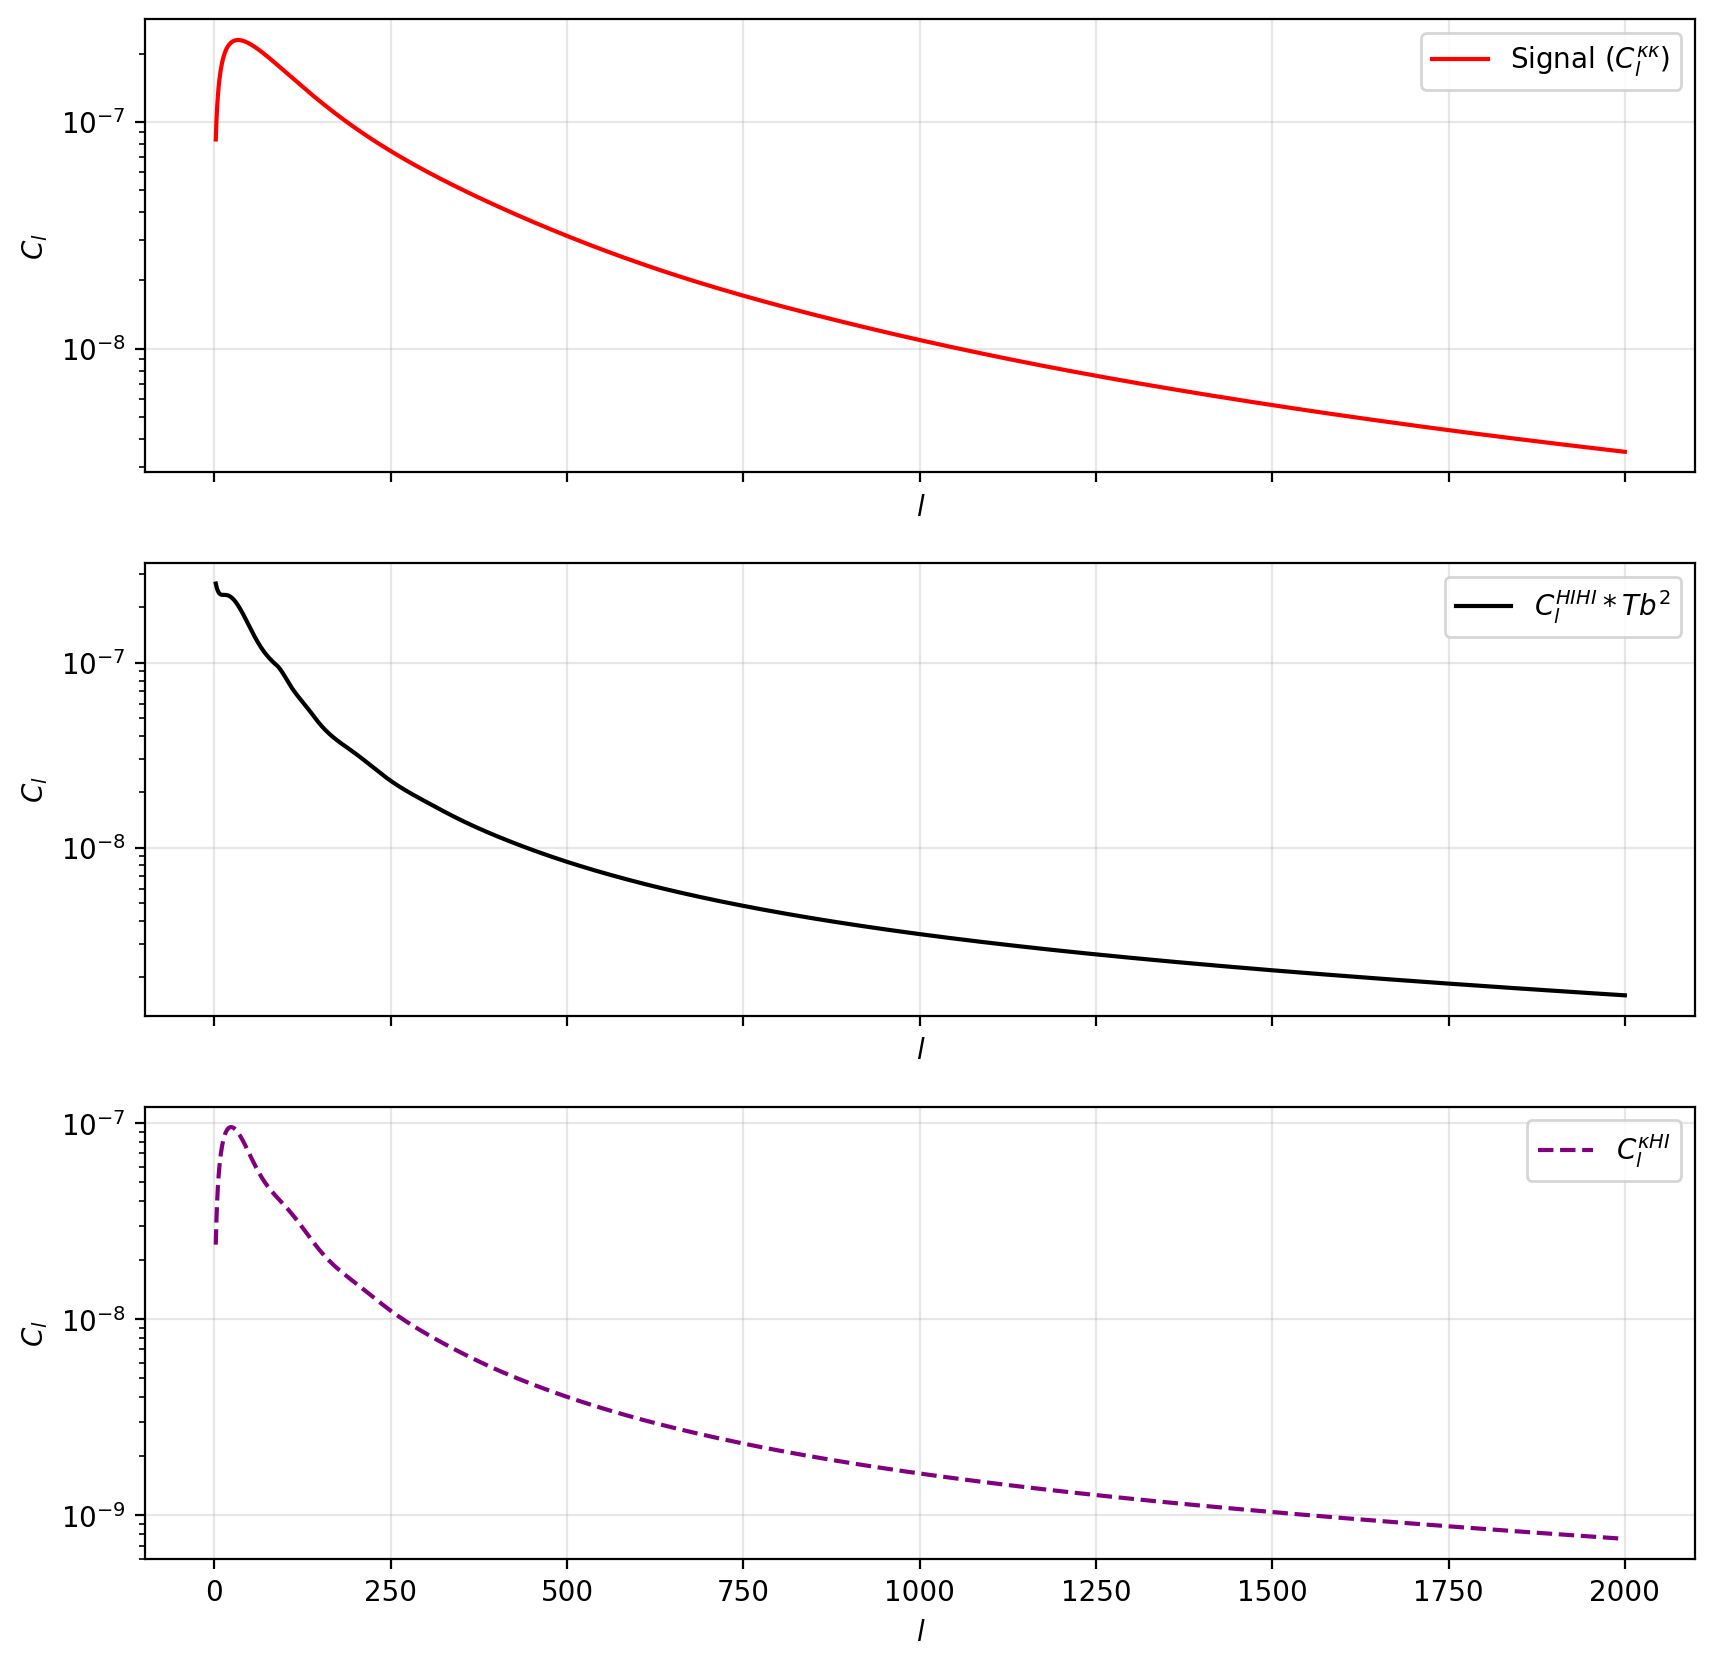

In [7]:
#plotting autos and cross power without noise

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax1.plot(ls[2:], cl_k_k[2:], color='red', label=r'Signal ($C_l^{\kappa \kappa}$)')
ax1.set_yscale('log')
ax1.set_ylabel(r'$C_l$')
ax1.set_xlabel(r'$l$')

ax1.grid(True, alpha=0.3)
ax1.legend()

#
ax2.plot(ls[2:], cl_hihi[2:], color='black', linestyle='-', label=r'$C_l^{HI HI} * Tb^2 $')
ax2.set_yscale('log')
ax2.set_ylabel(r'$C_l$')
ax2.set_xlabel(r'$l$')

ax2.grid(True, alpha=0.3)
ax2.legend()

#
ax3.plot(ls[2:], cl_k_hi[2:], color='purple', linestyle='--', label=r'$C_l^{\kappa HI}$')
ax3.set_yscale('log')
ax3.set_ylabel(r'$C_l$')
ax3.set_xlabel(r'$l$')

ax3.grid(True, alpha=0.3)
ax3.legend()


In [8]:
# HI shot NOISE - MeerKAT

from scipy.interpolate import splrep, splev


#in MHz, K
nu, Tsys_eta, a_eff=np.loadtxt('UHF_Tsys.txt',unpack=True)

def Tsys_mk(zc):
    """Returns interpolated system temperature in mK
    """
    ratio=0.72
    T_sys_meerkat_rep=splrep(nu,Tsys_eta)
    T_sys_meerkat=splev(HI/(1+zc),T_sys_meerkat_rep)*1e3
    return T_sys_meerkat*ratio

def P_N_instr(zc,Dzbin,omega,tobs):
    ## T is mK and HI in MHz.
    Tsys=Tsys_mk(zc)*10
    Dnu=HI*(1/(zc-Dzbin/2)-1/(zc+Dzbin/2))*1e6
    clinstr=Tsys**2*omega/(2*Ndishes*tobs*3600*Dnu)
    return clinstr

## Beam

def beam_no_ell(theta_fwhm):
    ## theta_fwhm in rad
    return np.exp(-theta_fwhm**2/16/np.log(2))

def theta_fwhm(lamb,D):
    ## lamb in m
    ## D in m
    return 1.22*lamb/D

def lamb(nu):
    ## nu in Hz
    return c_light*1e3/nu

def nu_obs(z):
    return HI/(1+z)

def theta(zc,D):
    lamb_obs=lamb(nu_obs(zc)*1e6)
    return theta_fwhm(lamb_obs,D)

def beam_l(beam_mk,l):
    return (beam_mk)**(l*(l+1))

### fixed parameters
Ndishes=60
Ddish=13.5
zc=0.61
HI=1420.4 #in MHz
c_light=3e8

zs=np.array([0.43,0.61,0.8,1.0,1.25])
Delta_z=np.array([0.06,0.18,0.2,0.2,0.3])

Sa=10000
Omega_surv=Sa*(np.pi/180)**2
t10k=1300
tobs=t10k*Sa/10000

#tobs=180
PN_HI = P_N_instr(zs,Delta_z,Omega_surv,tobs)

theta_fwhm_mk=theta(zc,Ddish)

beam_mk=beam_no_ell(theta_fwhm_mk)

PN_HI

beam_mk

np.float64(1.0477406592959851e-37)

In [9]:
# CMB Lensing noise

f_sky = 10000 / 41253.0
Tcmb=2.725e6 #micro K
theta_rad = np.radians(1/3) #from Bacon 2024

Npix=4*np.pi/theta_rad**2
print(Npix)
#50e6 #number of pixels observed from Bacon 2024
tpix= 3# 10.5 * 3600 #10.5 hours in Bacon 2024 time observed
tpix2=3.1536e7 #1 year


def Nl_kk(l):
    
    theta_fwhm = theta_rad
    sigma_b = theta_fwhm * 1 /( (8*np.log(2)**0.5) )
    s = 0.65 # microK s**0.5 (sensitivity)

    w_inv = 1e-6#4*np.pi * (s/Tcmb)**2 * 1/(tpix*Npix)  #variance per unit area, inversed
    print(w_inv)
    print((s/Tcmb)**2 )
    return f_sky * w_inv * np.exp((l**2) * (sigma_b**2))

371276.6512447735


1e-06
5.689756754481947e-14


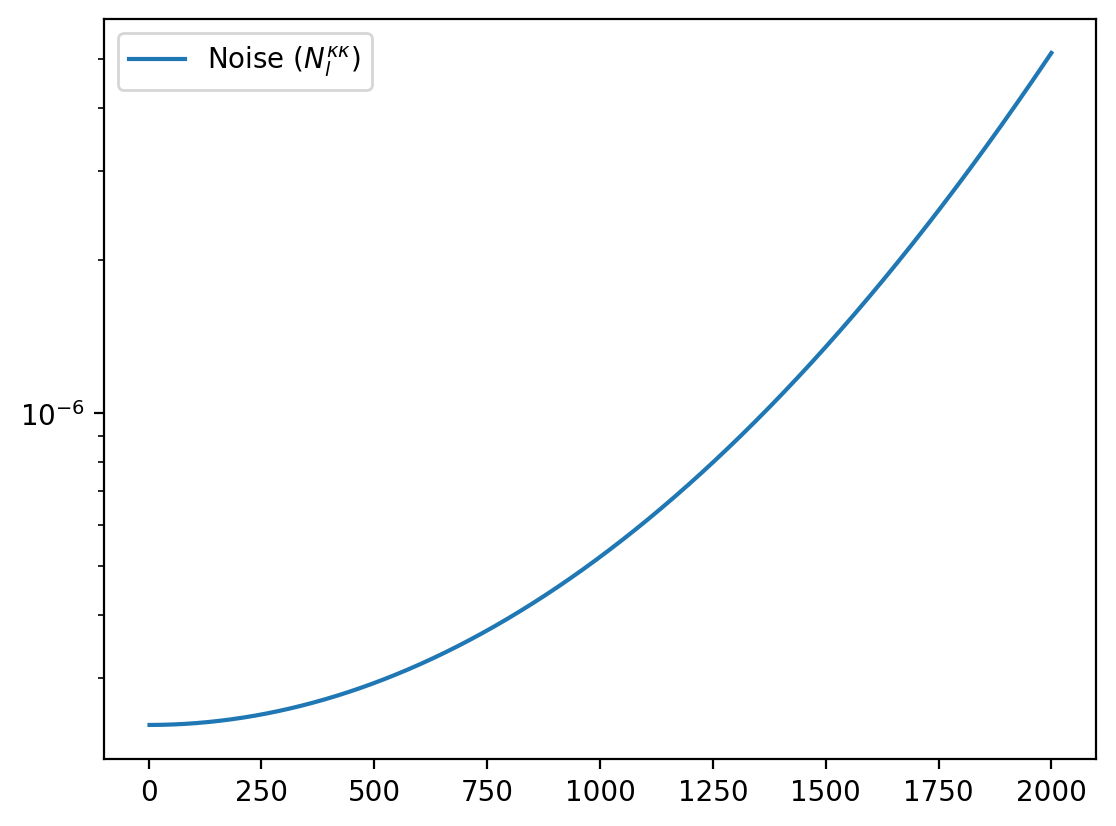

In [10]:
#Lensing Noise
plt.plot(ls[2:], Nl_kk(ls[2:]), label=r'Noise ($N_l^{\kappa \kappa}$)') 
plt.yscale('log')
plt.legend()

#plt.xlim(0,500) #Meerkat HI only gets to 

In [11]:

#Meerkat fraction of the sky  "MeerKLASS is designed to scan 4,000 degrees squared"
f_sky = 10000/ 41253.0 


zs=np.array([0.43,0.61,0.8,1.0,1.25])
Delta_z=np.array([0.06,0.18,0.2,0.2,0.3])

Sa=10000
Omega_surv=Sa*(np.pi/180)**2
t10k=1300
tobs=t10k*Sa/10000

zi = 0.61 #lets consider this redshift

N_hihi = P_N_instr(zs,Delta_z,Omega_surv,tobs)[1]

N_kk = Nl_kk(ls)

#Theoretical noise of cross power per multipole l - Giannantonio 2015
sigma_C_k_hi = np.zeros_like(ls, dtype=float)
for l in range(2, l_max + 1):
    variance = (cl_k_hi[l]**2) + (cl_k_k[l] + N_kk[l]) * (cl_hihi[l] + N_hihi)
    sigma_C_k_hi[l] = np.sqrt(variance / (f_sky * (2 * l + 1)))



1e-06
5.689756754481947e-14


In [12]:
N_hihi_array=np.ones_like(ls)*N_hihi
N_hihi_array


array([1.92836505e-07, 1.92836505e-07, 1.92836505e-07, ...,
       1.92836505e-07, 1.92836505e-07, 1.92836505e-07], shape=(2001,))

1e-06
5.689756754481947e-14


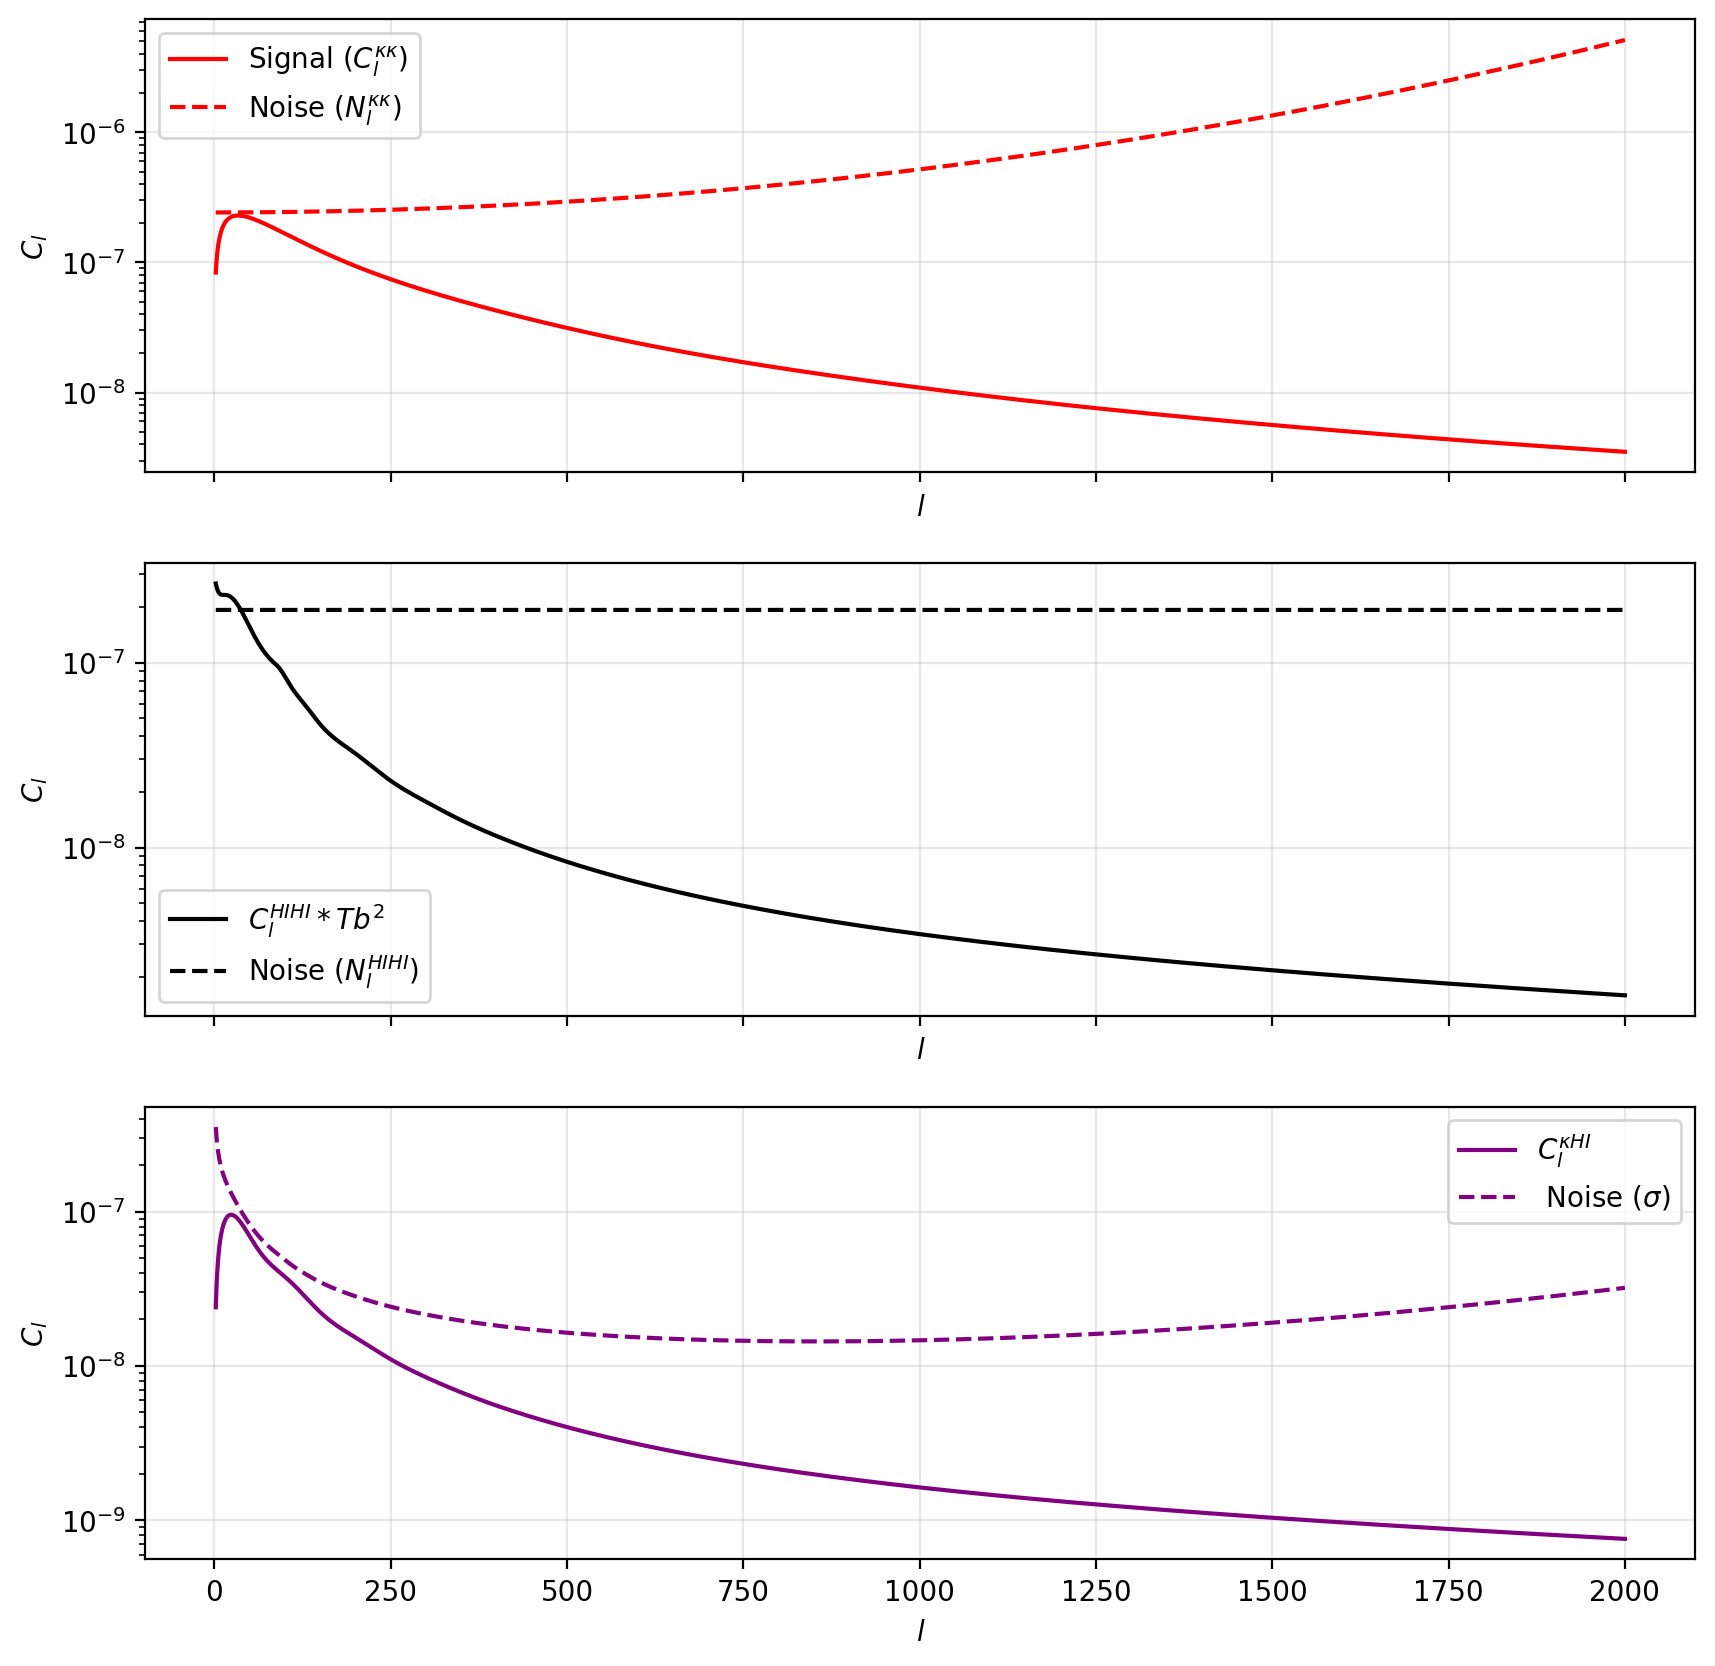

In [13]:

#Meerkat fraction of the sky  "MeerKLASS is designed to scan 4,000 degrees squared"
f_sky = 10000/ 41253.0 


zs=np.array([0.43,0.61,0.8,1.0,1.25])
Delta_z=np.array([0.06,0.18,0.2,0.2,0.3])

Sa=10000
Omega_surv=Sa*(np.pi/180)**2
t10k=1300
tobs=t10k*Sa/10000

zi = 0.61 #lets consider this redshift

N_hihi = P_N_instr(zs,Delta_z,Omega_surv,tobs)[1]

N_kk = Nl_kk(ls)

#Theoretical noise of cross power per multipole l - Giannantonio 2015
sigma_C_k_hi = np.zeros_like(ls, dtype=float)
for l in range(2, l_max + 1):
    variance = (cl_k_hi[l]**2) + (cl_k_k[l] + N_kk[l]) * (cl_hihi[l] + N_hihi)
    sigma_C_k_hi[l] = np.sqrt(variance / (f_sky * (2 * l + 1)))







#plotting autos and cross power without noise

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax1.plot(ls[2:], cl_k_k[2:], color='red', label=r'Signal ($C_l^{\kappa \kappa}$)')
ax1.plot(ls[2:], N_kk[2:], color='red', linestyle='--', label=r'Noise ($N_l^{\kappa \kappa}$)')
ax1.set_yscale('log')
ax1.set_ylabel(r'$C_l$')
ax1.set_xlabel(r'$l$')

ax1.grid(True, alpha=0.3)
ax1.legend()

#
ax2.plot(ls[2:], cl_hihi[2:], color='black', linestyle='-', label=r'$C_l^{HI HI} * Tb^2 $')
ax2.plot(ls[2:], N_hihi_array[2:], color='black', linestyle='--', label=r'Noise ($N_l^{HI HI}$)')
ax2.set_yscale('log')
ax2.set_ylabel(r'$C_l$')
ax2.set_xlabel(r'$l$')

ax2.grid(True, alpha=0.3)
ax2.legend()

#
ax3.plot(ls[2:], cl_k_hi[2:], color='purple', label=r'$C_l^{\kappa HI}$')
ax3.plot(ls[2:], sigma_C_k_hi[2:], color='purple', linestyle='--', label=r' Noise ($\sigma$)')
ax3.set_yscale('log')
ax3.set_ylabel(r'$C_l$')
ax3.set_xlabel(r'$l$')
#ax3.set_xlim(0,1000)

ax3.grid(True, alpha=0.3)
ax3.legend()


In [14]:
#plot snr
#  Calculate Cumulative SNR (Equation 16 giannantonio 2015) ---
cumulative_snr = np.zeros_like(ls, dtype=float)
snr_squared_sum = 0.0

snr_l_sq = f_sky*(2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k + N_kk) * (cl_hihi + N_hihi))

cumulative_snr = np.sqrt(np.cumsum(snr_l_sq[2:]))

snr_l_sq_th = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k) * (cl_hihi))


cumulative_snr_th = np.sqrt(np.cumsum(snr_l_sq_th[2:]))



/var/folders/_n/vm9nc6_54_1_2m60q4p1xhww0000gn/T/ipykernel_86530/3410662017.py:10: RuntimeWarning: invalid value encountered in divide
  snr_l_sq_th = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k) * (cl_hihi))


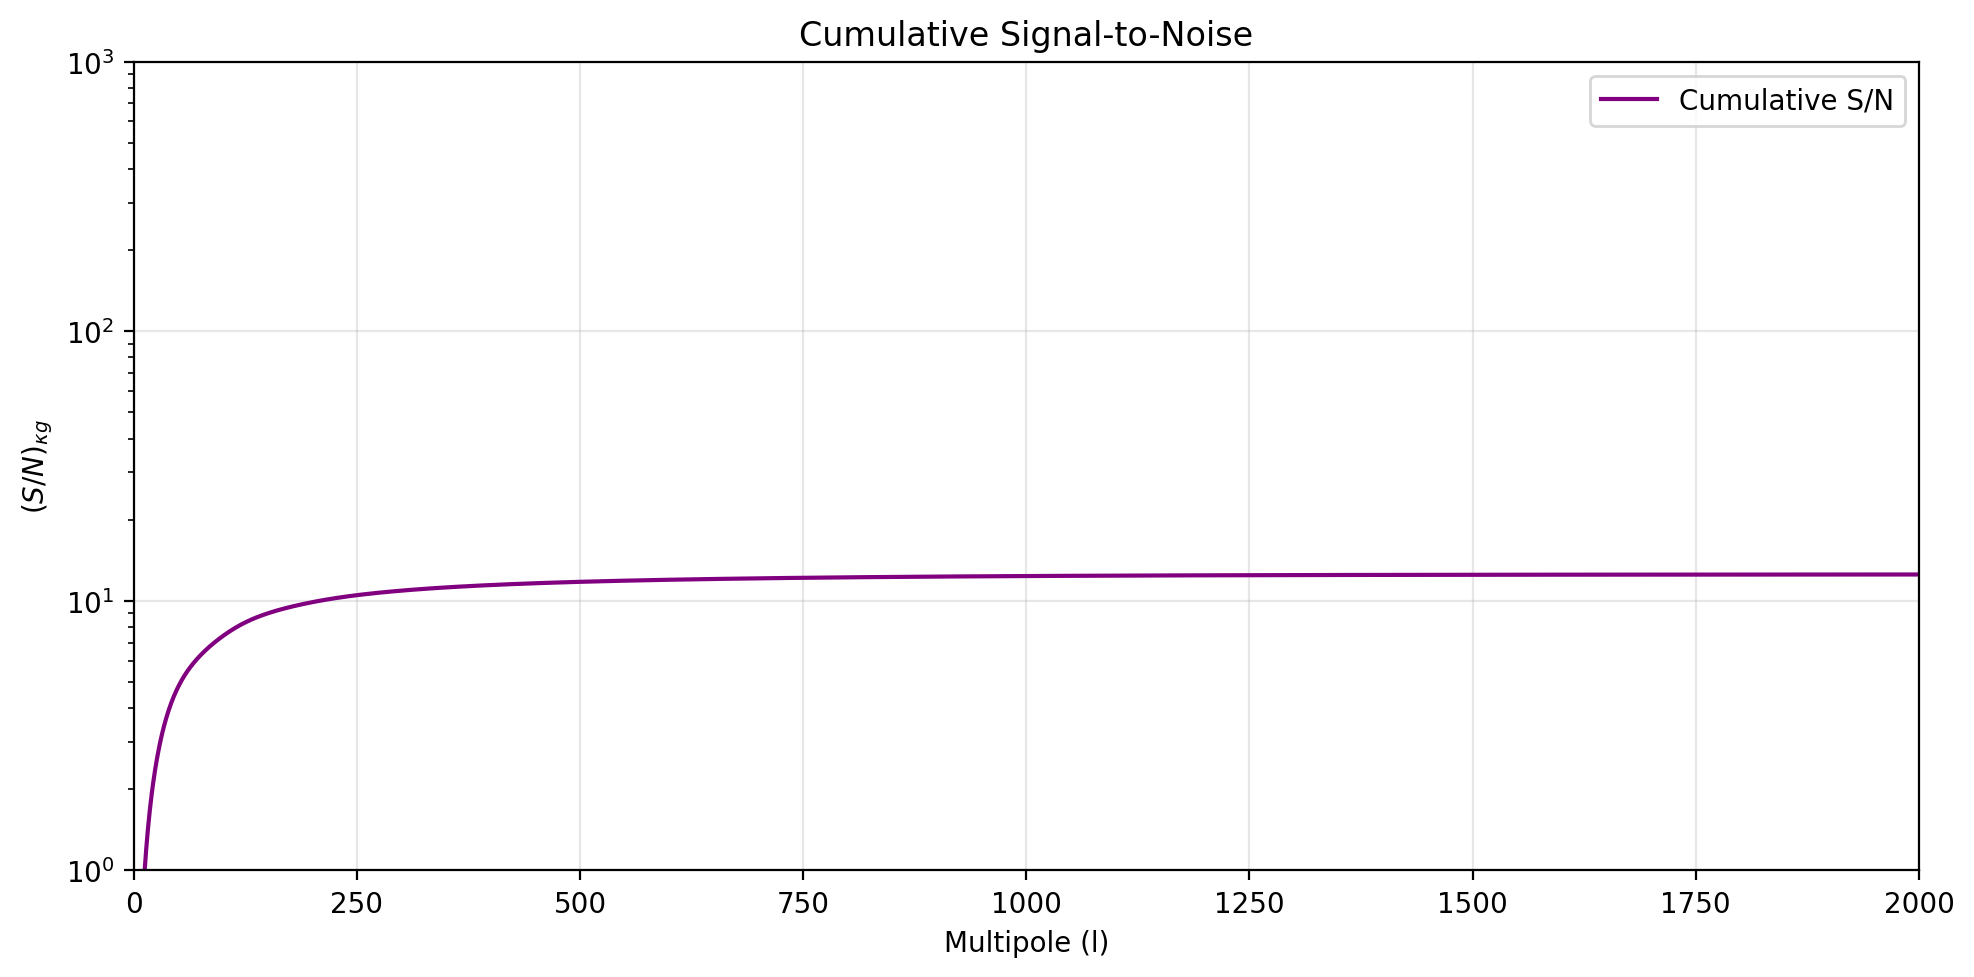

In [15]:

fig, (ax3) = plt.subplots(1, 1, figsize=(10, 5), sharex=True)
# Bottom: Cumulative SNR
ax3.plot(ls[2:], cumulative_snr, color='purple', label='Cumulative S/N')
#ax3.plot(ls[2:], cumulative_snr_th, color='blue', label='Cumulative S/N Th')

ax3.set_yscale('log')
ax3.set_ylabel(r'$(S/N)_{\kappa g}$')
ax3.set_xlabel('Multipole (l)')
ax3.set_title('Cumulative Signal-to-Noise')
ax3.set_xlim(0, 2000)
ax3.set_ylim(1, 1000) # Adjust based on expected DES-SV SNR (~5-8)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Lensing Noise using LensQuEst

In [37]:
from importlib import reload

import universe
reload(universe)
from universe import *

import halo_fit
reload(halo_fit)
from halo_fit import *

import weight
reload(weight)
from weight import *

import pn_2d
reload(pn_2d)
from pn_2d import *

import cmb
reload(cmb)
from cmb import *

import flat_map
reload(flat_map)
from flat_map import *

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath} \usepackage{amssymb}'


In [38]:
#MeerkAt params and Cls forecasting

M_pars = camb.CAMBparams()
M1_pars = camb.CAMBparams() # "without lensing"

M_pars.set_cosmology(H0=67.8, ombh2=0.0222, omch2=0.119, mnu=0.06, omk=0, tau=0.0952)  #flat ACDM-nu cosmology
M_pars.InitPower.set_params(As=2.21e-9, ns=0.961)

#we want CMB lensing
M_pars.Want_CMB_lensing = True
M_pars.set_for_lmax(2000, lens_potential_accuracy=1)

M1_pars = M_pars.copy()
M1_pars.Want_CMB_lensing = False


#results
results = camb.get_results(M_pars)
results1 = camb.get_results(M1_pars)

# extract spectra disctionary (window x power ...)
cls = results.get_source_cls_dict(raw_cl=True)
cls_unl = results1.get_source_cls_dict(raw_cl=True)

# Lensing Potential auto-spectrum (PxP)
cl_phi_phi = cls['PxP'][:l_max+1]
clun_phi_phi = cls_unl['PxP'][:l_max+1]

scaling_factor = (ls * (ls + 1)) / 2.0

# potential to Convergence auto-spectrum (kappa-kappa)
cl_k_k = (scaling_factor**2) * cl_phi_phi 
clun_k_k = (scaling_factor**2) * clun_phi_phi 


#get ready for Lensquest
ell_camb = ls[2:]

camb_unlensed_TT = clun_k_k[2:]
camb_lensed_TT = cl_k_k[2:]




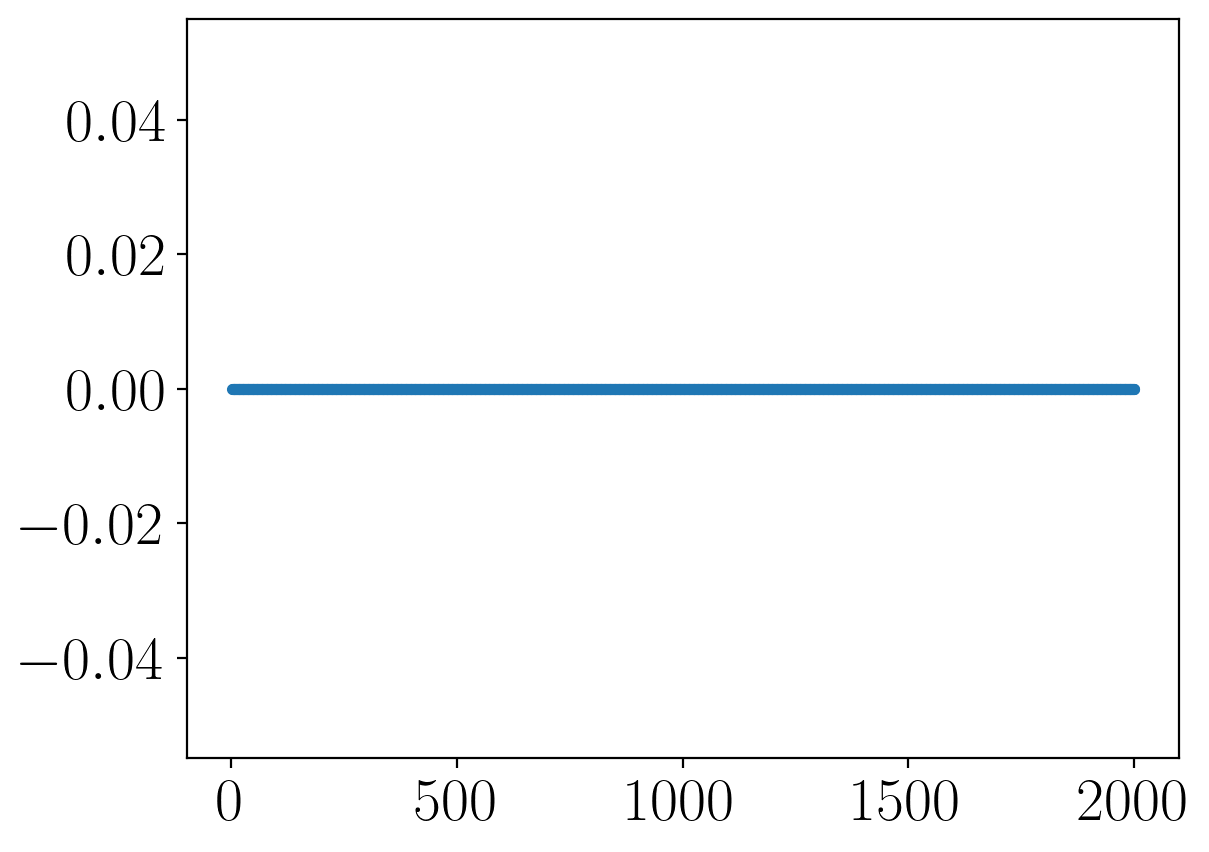

In [39]:

plt.plot(ell_camb, camb_unlensed_TT-camb_lensed_TT,'.')
#plt.plot(ell_camb, camb_lensed_TT,'.')

In [40]:
camb_unlensed_TT-camb_lensed_TT

array([0., 0., 0., ..., 0., 0., 0.], shape=(1999,))

In [41]:
# Set up parameters as you did
M_pars = camb.CAMBparams()
M_pars.set_cosmology(H0=67.8, ombh2=0.0222, omch2=0.119, mnu=0.06, omk=0, tau=0.0952)
M_pars.InitPower.set_params(As=2.21e-9, ns=0.961)

# You ONLY need one parameter object. If you turn on Want_CMB_lensing, 
# CAMB calculates both lensed and unlensed automatically in the same run!
M_pars.Want_CMB_lensing = True
M_pars.set_for_lmax(2000, lens_potential_accuracy=1)

# Get results
results = camb.get_results(M_pars)

# --- GETTING THE LENSING SIGNAL ---

cls = results.get_source_cls_dict(raw_cl=True)
cl_phi_phi = cls['PxP'][:2001]
ls = np.arange(2001)
scaling_factor = (ls * (ls + 1)) / 2.0
cl_k_k = (scaling_factor**2) * cl_phi_phi 

# --- GETTING THE TEMPERATURE SPECTRA ---
# To get lensed vs unlensed TT, use `get_cmb_power_spectra`
powers = results.get_cmb_power_spectra(M_pars, CMB_unit='muK', raw_cl=True)

# powers['unlensed_scalar'] is an array where columns are [TT, EE, BB, TE]
camb_unlensed_TT = powers['unlensed_scalar'][:2001, 0]

# powers['total'] contains the lensed spectra
camb_lensed_TT = powers['total'][:2001, 0]

# Now you can verify they are different!
print(np.sum(camb_unlensed_TT - camb_lensed_TT)) 

# Drop the L=0 and L=1 terms for LensQuEst
ell_camb = ls[2:]
camb_unlensed_TT = camb_unlensed_TT[2:]
camb_lensed_TT = camb_lensed_TT[2:]
signal_cl_k_k = cl_k_k[2:]

-0.1927200715265293


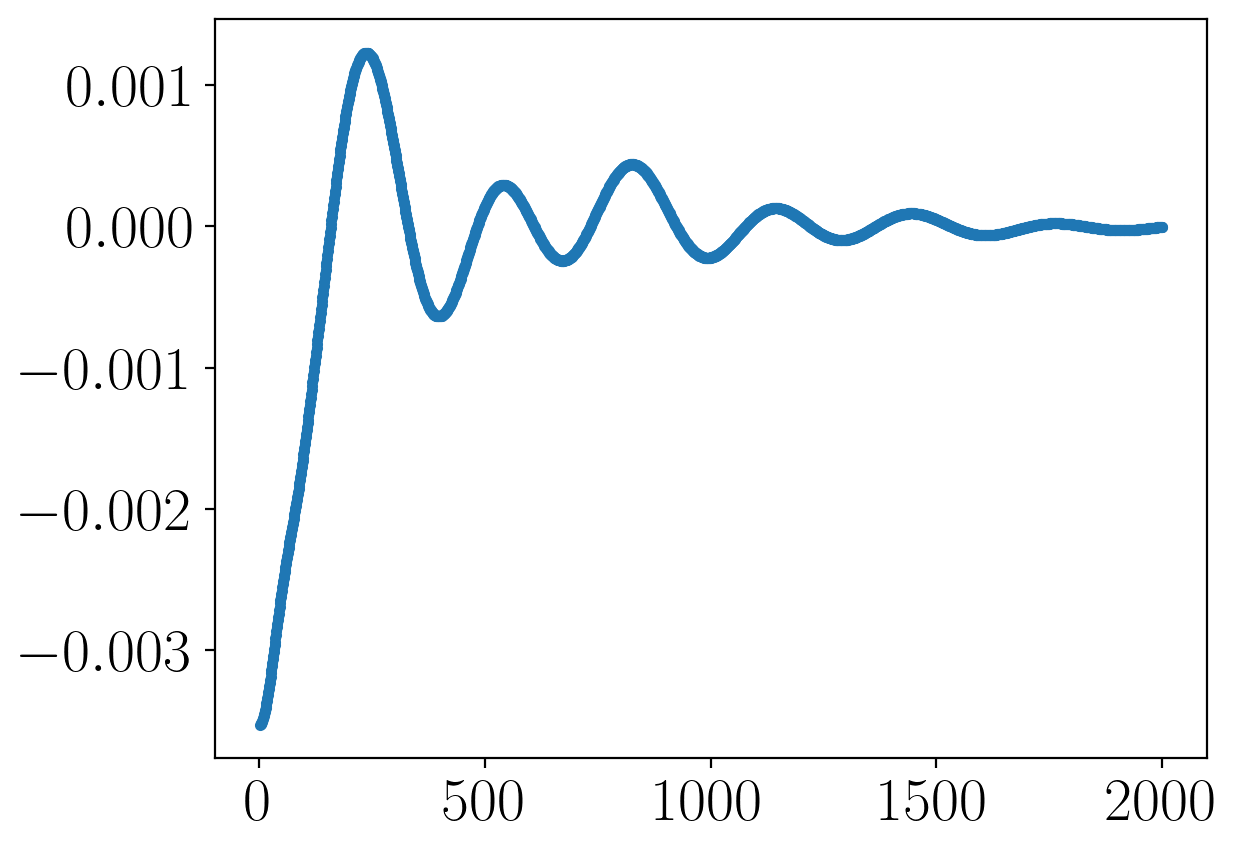

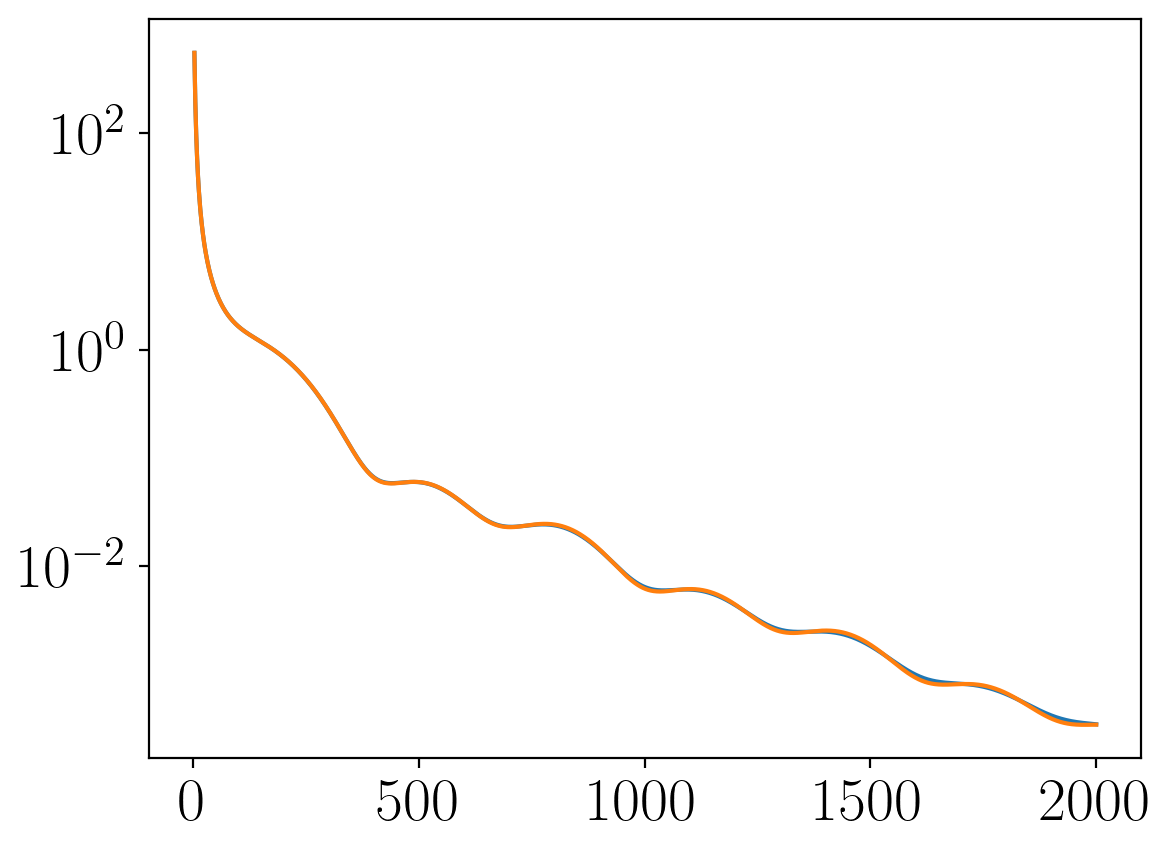

In [42]:
plt.plot(ell_camb, camb_unlensed_TT-camb_lensed_TT,'.')
plt.show()
plt.plot(ell_camb[1:], camb_lensed_TT[1:])
plt.plot(ell_camb[1:], camb_unlensed_TT[1:])
plt.yscale('log')

In [43]:
import numpy as np
import camb
from camb import sources
from scipy.interpolate import interp1d

# --- 1. YOUR EXACT CAMB SETUP ---
M_pars = camb.CAMBparams()
M_pars.set_cosmology(H0=67.8, ombh2=0.0222, omch2=0.119, mnu=0.06, omk=0, tau=0.0952) 
M_pars.InitPower.set_params(As=2.21e-9, ns=0.961)

zi = 0.61
b = 1.0 # (Assuming bias_HI(zi) returns 1.0 for this example)
M_pars.SourceWindows = [
    sources.GaussianSourceWindow(source_type='counts', bias=b, redshift=zi, sigma=0.15)
]

M_pars.Want_CMB_lensing = True
M_pars.set_for_lmax(2000, lens_potential_accuracy=1)
results = camb.get_results(M_pars)

# --- 2. EXTRACT YOUR C_L^{\kappa\kappa} (SIGNAL) ---
cls = results.get_source_cls_dict(raw_cl=True)
l_max = 2000
ls = np.linspace(0, l_max, 2001)

cl_phi_phi = cls['PxP'][:l_max+1]
scaling_factor = (ls * (ls + 1)) / 2.0
cl_k_k = (scaling_factor**2) * cl_phi_phi # <--- C_L^\kappa\kappa

# --- 3. EXTRACT TT SPECTRA FOR LENSQUEST NOISE ---
# We must get the TT spectra from your specific CAMB run so the noise 
# matches your cosmology perfectly.
powers = results.get_cmb_power_spectra(M_pars, CMB_unit='muK', raw_cl=True)
camb_unlensed_TT = powers['unlensed_scalar'][:l_max+1, 0]
camb_lensed_TT = powers['total'][:l_max+1, 0]

# --- 4. USE LENSQUEST PURELY AS A NOISE CALCULATOR ---
from flat_map import FlatMap
from cmb import StageIVCMB

# Setup dummy map for the FFT integrals
baseMap = FlatMap(nX=400, nY=400, sizeX=10., sizeY=10.)

# Turn YOUR CAMB arrays into functions LensQuEst can read
my_funlensedTT = interp1d(ls[2:], camb_unlensed_TT[2:], bounds_error=False, fill_value=0.)
my_flensedTT = interp1d(ls[2:], camb_lensed_TT[2:], bounds_error=False, fill_value=0.)

# Add experimental detector noise (e.g., Stage IV specs) to your lensed TT  DO WE WANT DETECTOR NOISE?
# This is the only "LensQuEst" assumption we are keeping
cmb_exp = StageIVCMB(beam=1., noise=1., lMin=30., lMaxT=2000., lMaxP=2000., atm=False)
my_fCtotal = lambda l: my_flensedTT(l) #+ cmb_exp.fdetectorNoise(l)

# Compute the Noise (N_L^{\kappa\kappa}) using YOUR TT spectra!
fNq = baseMap.forecastN0Kappa(my_funlensedTT, my_fCtotal, lMin=30., lMax=2000., test=False)

# Evaluate the final noise array on your CAMB multipoles
Nl_kk = fNq(ls[2:]) # <--- YOUR GUARANTEED N_L^\kappa\kappa


print(f"First valid Signal Cl_kk (L=2): {cl_k_k[2]}")
print(f"First valid Noise Nl_kk (L=2): {Nl_kk[0]}")

computing the reconstruction noise
Doing full calculation: computeQuadEstPhiNormalizationFFT
First valid Signal Cl_kk (L=2): 8.376301488133965e-08
First valid Noise Nl_kk (L=2): 2.8872812990413753e-06


/Users/l_luciano__/Desktop/J/CMB Lensing/flat_map.py:1655: RuntimeWarning: divide by zero encountered in divide
  resultFourier = 1./resultFourier
/Users/l_luciano__/Desktop/J/CMB Lensing/flat_map.py:1655: RuntimeWarning: invalid value encountered in divide
  resultFourier = 1./resultFourier


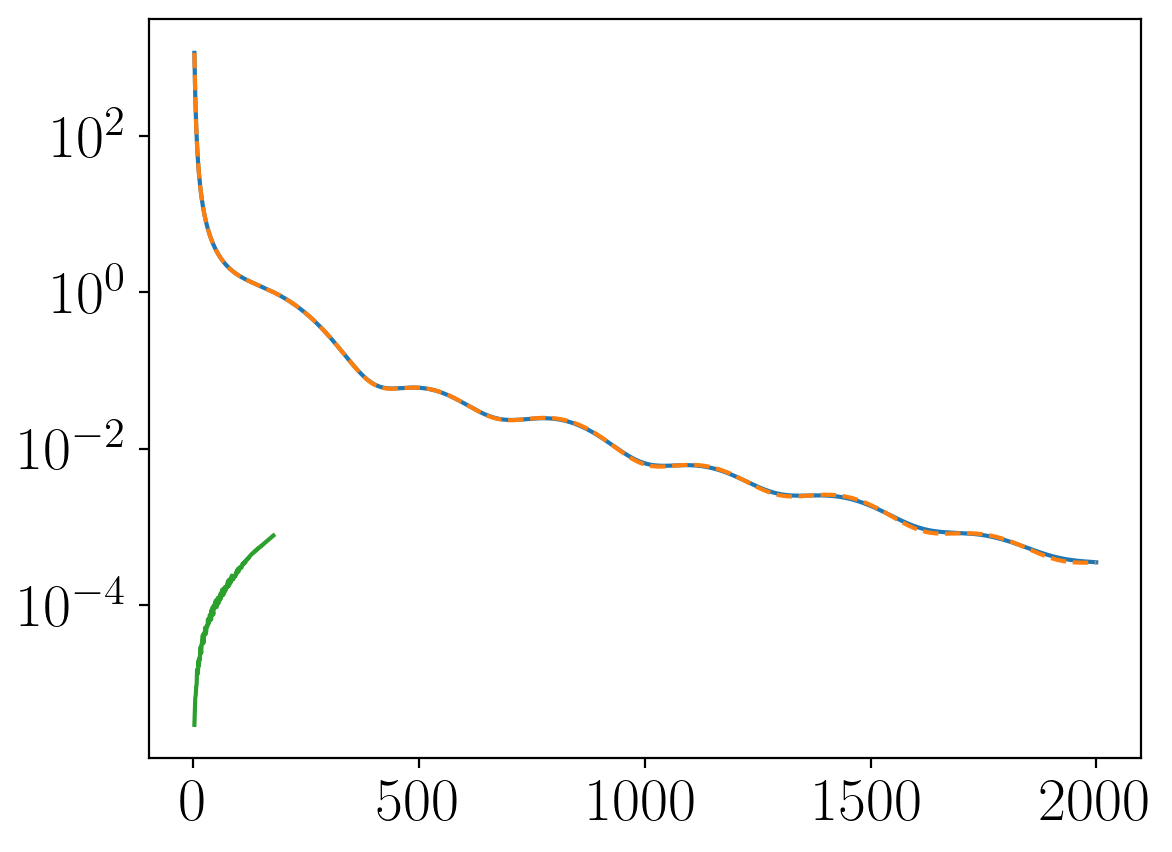

In [44]:
plt.plot(ls[2:],camb_lensed_TT[2:])
plt.plot(ls[2:],camb_unlensed_TT[2:],'--')
plt.plot(ls[2:],Nl_kk)
plt.yscale('log')

# LENSQUEST NOISE

In [77]:
# START OVER 

from importlib import reload

import universe
reload(universe)
from universe import *

import halo_fit
reload(halo_fit)
from halo_fit import *

import weight
reload(weight)
from weight import *

import pn_2d
reload(pn_2d)
from pn_2d import *

import cmb
reload(cmb)
from cmb import *

import flat_map
reload(flat_map)
from flat_map import *

In [78]:
#map for MeerKlass

#MeerKat
# Target Area: 10,000 square degrees
# Target Pixels: ~371,276

# A 609 x 609 grid yields 370,881 pixels and keeps pixels square
nXM = 609
nYM = 609

# Square root of 10,000 sq degrees is 100 degrees per side
sizeX_degM = 100.
sizeY_degM = 100.

# Initialize the map (LensQuEst expects radians, so we multiply by pi/180)
baseMapM = FlatMap(nX=nXM, nY=nYM, sizeX=sizeX_degM*np.pi/180., sizeY=sizeY_degM*np.pi/180.)

# multipoles to include in the lensing reconstruction
lMin = 10.; lMax = 3.5e3
# ell bins for power spectra
nBins = 21  # number of bins
lRange = (1., 2.*lMax)  # range for power spectra

In [79]:
print("CMB experiment properties")

# Adjust the lMin and lMax to the assumptions of the analysis
# CMB S3 specs
cmb = StageIVCMB(beam=1., noise=0., lMin=lMin, lMaxT=lMax, lMaxP=lMax*1.7, atm=False)

# Total power spectrum, for the lens reconstruction
forCtotal = lambda l: cmb.flensedTT(l) + cmb.fdetectorNoise(l)
#
# reinterpolate: gain factor 10 in speed
L = np.logspace(np.log10(lMin/2.), np.log10(2.*lMax), 1001, 10.)

l_max = 3.5e3
ls = np.linspace(10, l_max, 2001)

#F = np.array(map(forCtotal, L))
F = np.array(list(map(forCtotal, L)))
cmb.fCtotal = interp1d(L, F, kind='linear', bounds_error=False, fill_value=0.)

CMB experiment properties


In [80]:
cmb.fCtotal(ls)

array([4.74604912e+01, 3.50501858e+01, 2.71780173e+01, ...,
       5.35017392e-06, 5.32192750e-06, 5.29368107e-06], shape=(2001,))

In [81]:
print("CMB lensing power spectrum")

u = UnivMeerKlass()
#u = UnivPlanck15()
halofit = Halofit(u, save=False)
w_cmblens = WeightLensSingle(u, z_source=1100., name="cmblens")
p2d_cmblens = P2dAuto(u, halofit, w_cmblens, save=False)

Clkk=p2d_cmblens.fPinterp(ls)



CMB lensing power spectrum


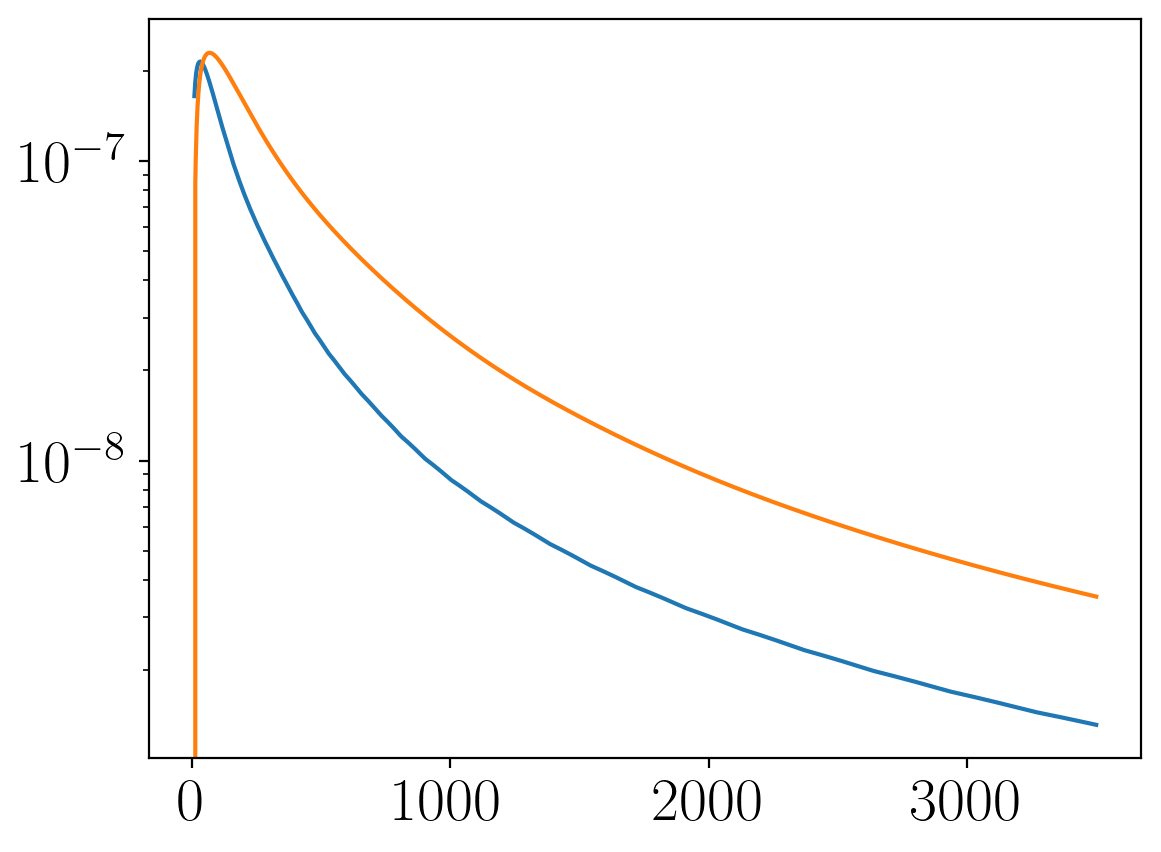

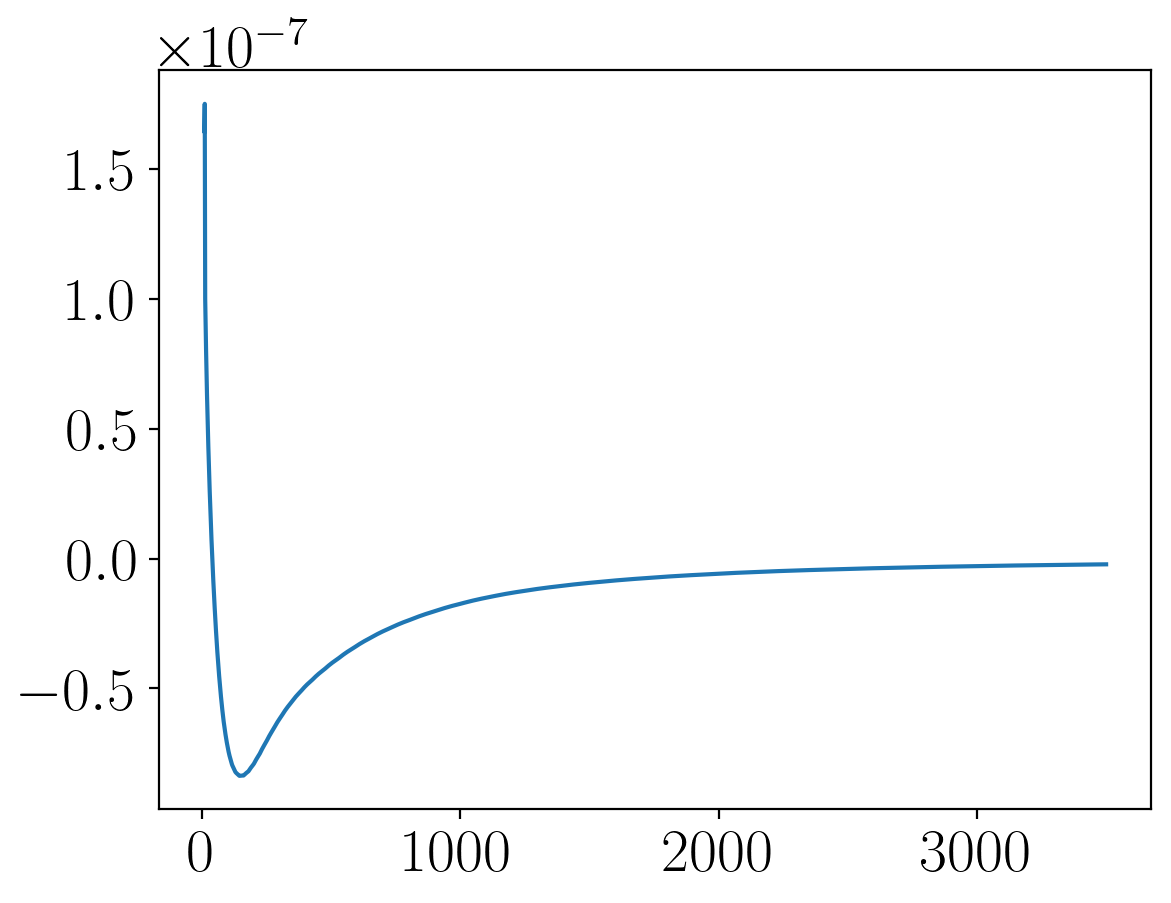

In [83]:
plt.plot(ls[0:],Clkk[0:])
plt.plot(ls[0:],cl_k_k[0:])
plt.yscale('log')
plt.show()

plt.plot(ls[0:], (Clkk-cl_k_k)[0:])

In [75]:
print("- standard quadratic estimator")
fNqCmb_fft = baseMapM.forecastN0Kappa(cmb.funlensedTT, cmb.fCtotal, lMin=lMin, lMax=lMax, test=False)

- standard quadratic estimator
computing the reconstruction noise
Doing full calculation: computeQuadEstPhiNormalizationFFT


/Users/l_luciano__/Desktop/J/CMB Lensing/flat_map.py:1655: RuntimeWarning: divide by zero encountered in divide
  resultFourier = 1./resultFourier
/Users/l_luciano__/Desktop/J/CMB Lensing/flat_map.py:1655: RuntimeWarning: invalid value encountered in divide
  resultFourier = 1./resultFourier


Text(0, 0.5, '$C_L^\\kappa$')

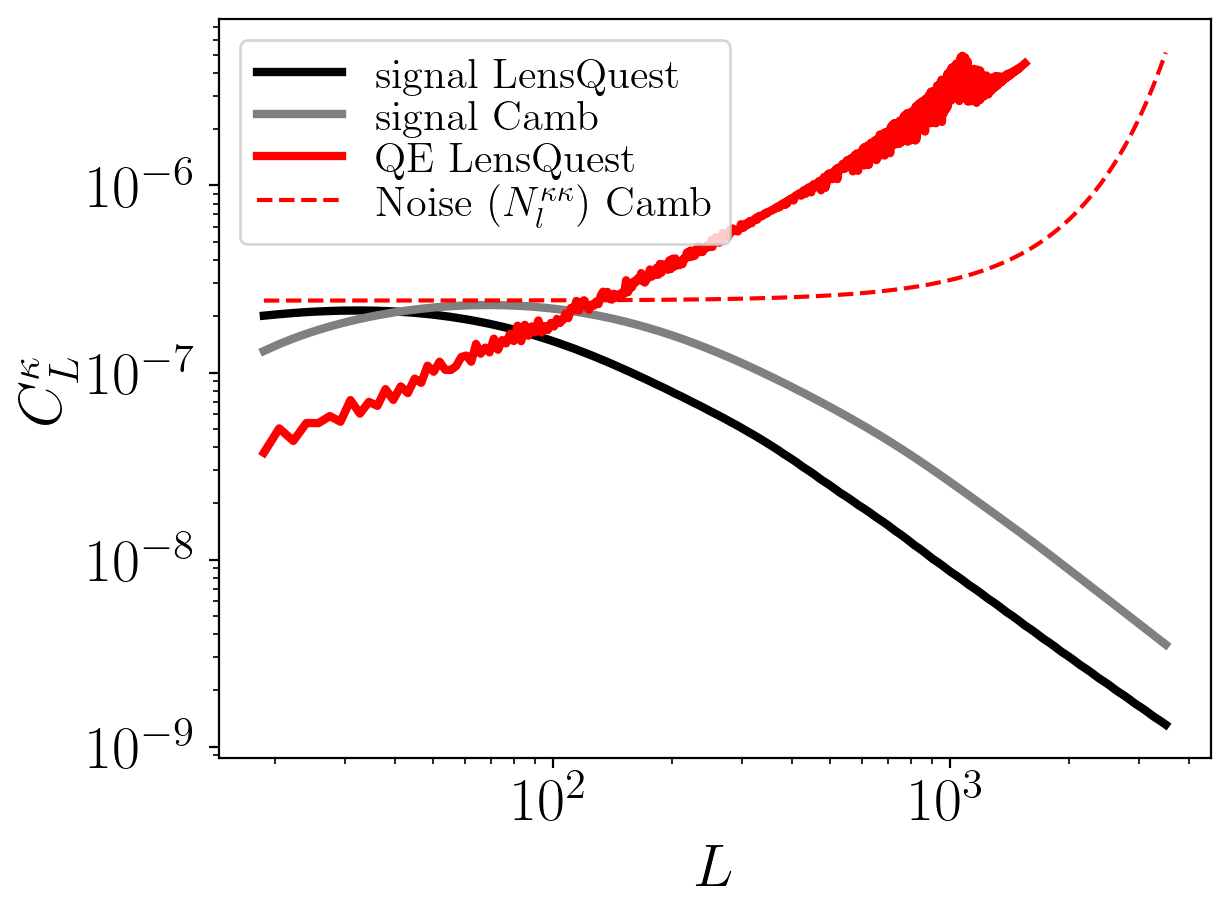

In [76]:
Nq = fNqCmb_fft(ls)
Clq = p2d_cmblens.fPinterp(ls)

fig=plt.figure(0)
ax=fig.add_subplot(111)
#
ax.loglog(ls[5:], Clq[5:], 'k-', lw=3, label=r'signal LensQuest')
ax.loglog(ls[5:], cl_k_k[5:], 'gray', lw=3, label=r'signal Camb')

ax.loglog(ls[5:], Nq[5:], c='r', lw=3, label=r'QE LensQuest')
ax.loglog(ls[5:], N_kk[5:], color='red', linestyle='--', label=r'Noise ($N_l^{\kappa \kappa}$) Camb')


ax.legend(loc=2, fontsize='x-small', labelspacing=0.1)
ax.set_xlabel(r'$L$')
ax.set_ylabel(r'$C_L^\kappa$')

1e-06
5.689756754481947e-14


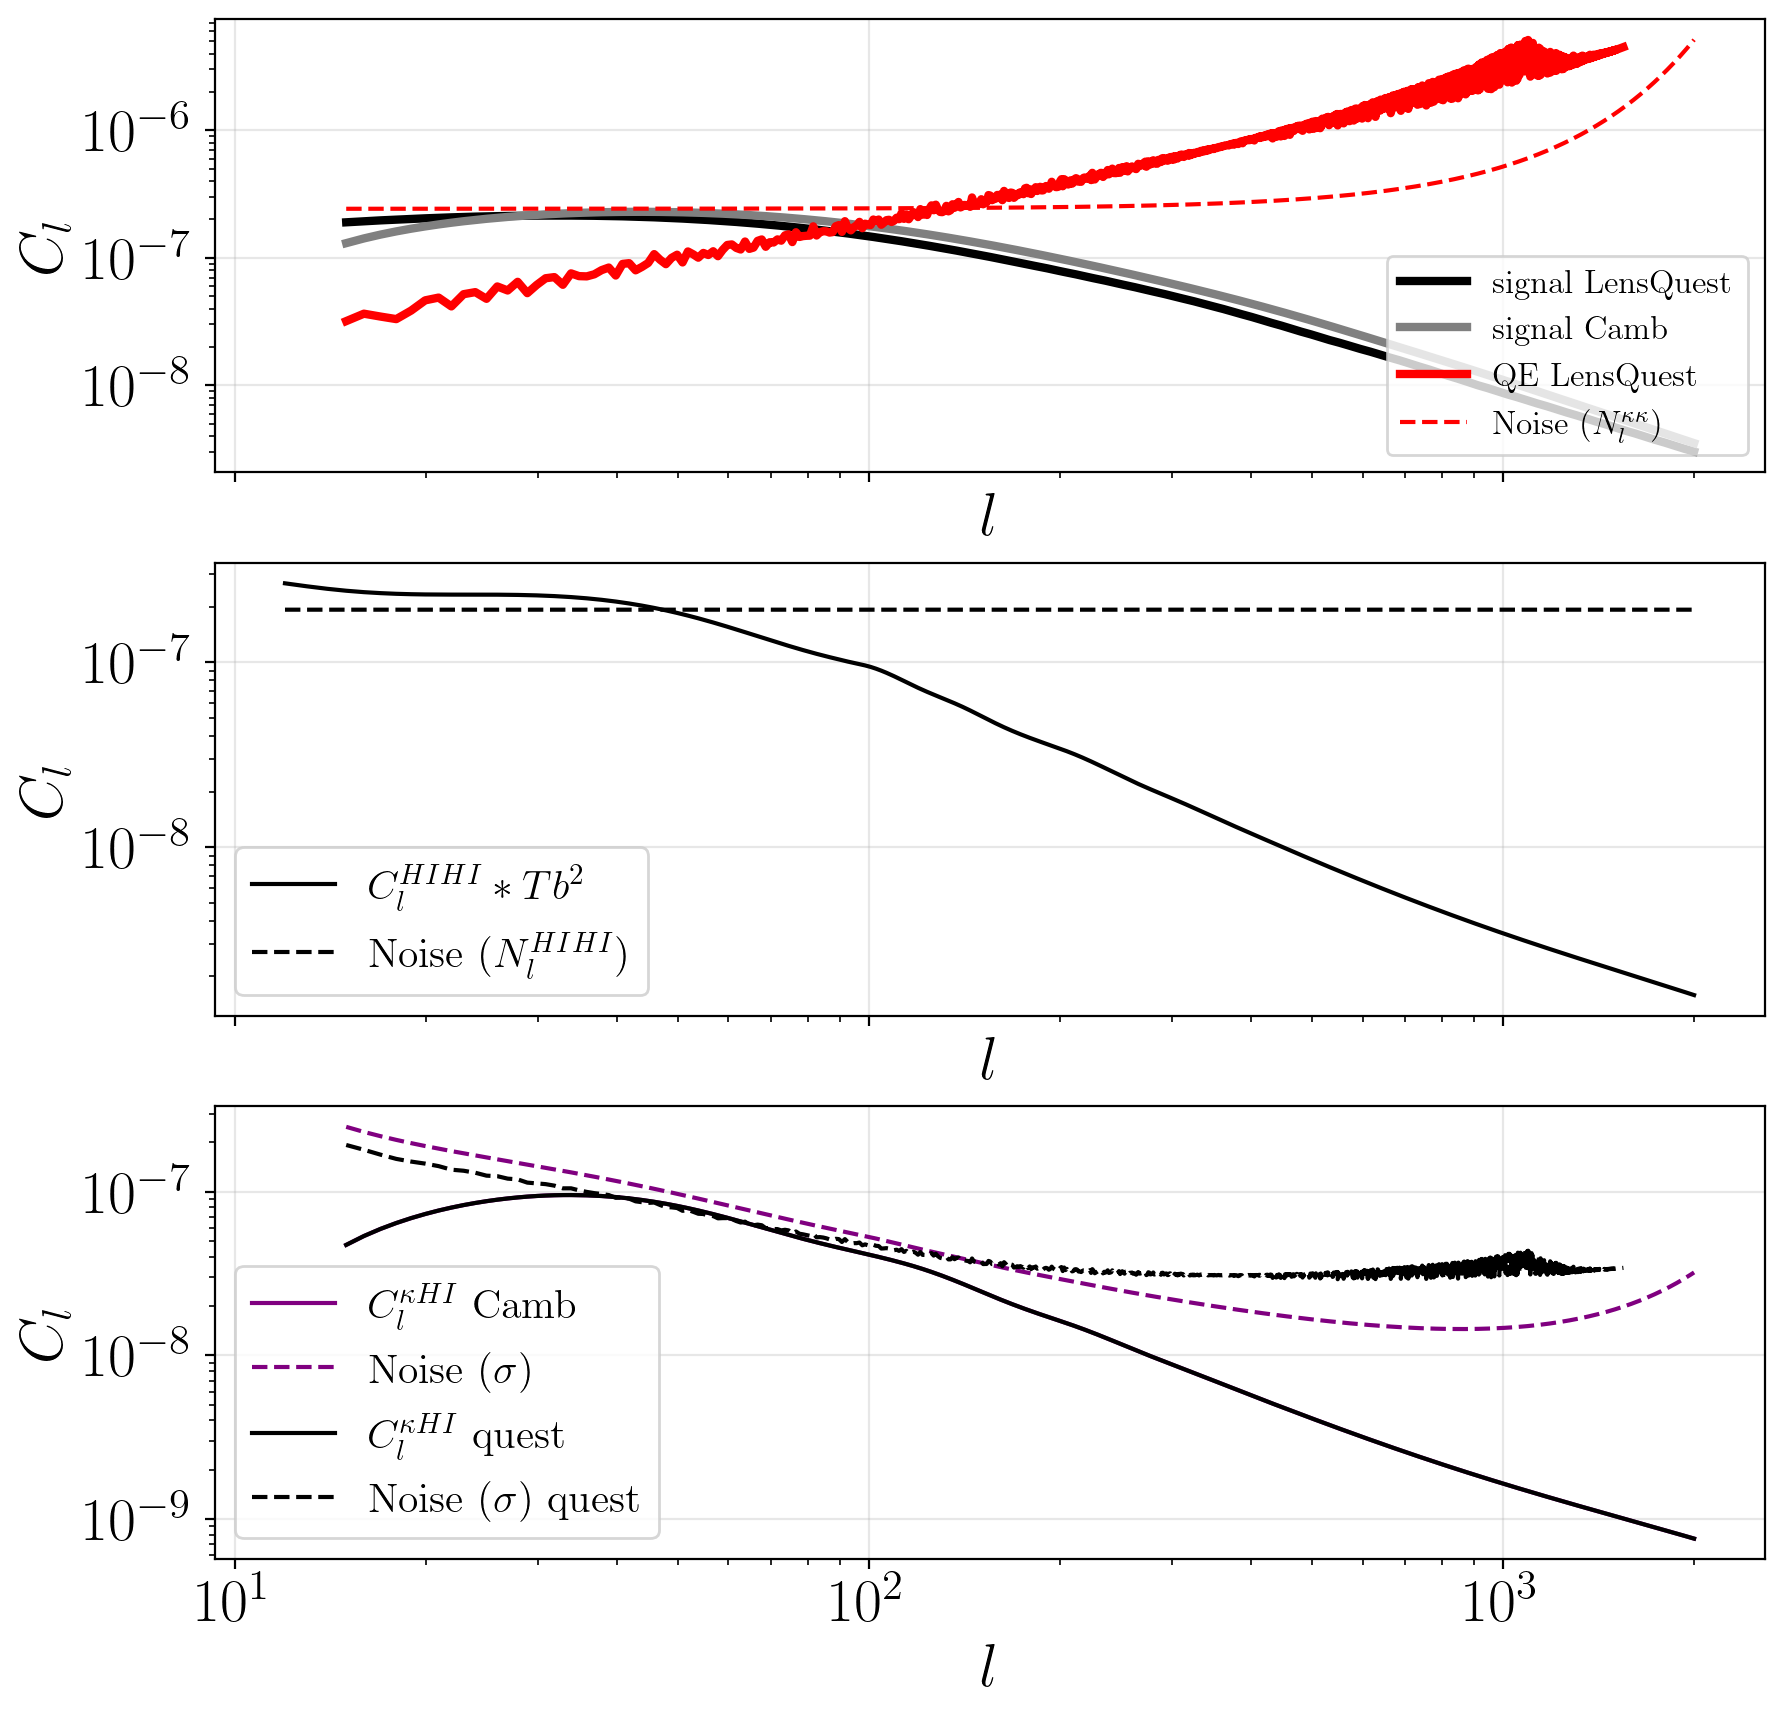

In [67]:

def Nl_kk(l):
    
    theta_fwhm = theta_rad
    sigma_b = theta_fwhm * 1 /( (8*np.log(2)**0.5) )
    s = 0.65 # microK s**0.5 (sensitivity)

    w_inv = 1e-6#4*np.pi * (s/Tcmb)**2 * 1/(tpix*Npix)  #variance per unit area, inversed
    print(w_inv)
    print((s/Tcmb)**2 )
    return f_sky * w_inv * np.exp((l**2) * (sigma_b**2))


#Meerkat fraction of the sky 
f_sky = 10000/ 41253.0 


#zs=np.array([0.43,0.61,0.8,1.0,1.25])
#Delta_z=np.array([0.06,0.18,0.2,0.2,0.3])
#faz o SNR para cada um e o SNR total de todos combinados
#zs=np.array([0.61,0.8,1.0])
#Delta_z=np.array([0.18,0.2,0.2])
#SNR de um único bin
#zs=np.array([0.81])
#Delta_z=np.array([0.58])

Sa=10000
Omega_surv=Sa*(np.pi/180)**2
t10k=1300
tobs=t10k*Sa/10000

ls=np.linspace(10,2000,2001)

zi = 0.61 #lets consider this redshift

N_hihi = P_N_instr(zs,Delta_z,Omega_surv,tobs)[1]

N_kk = Nl_kk(ls)



#Theoretical noise of cross power per multipole l - Giannantonio 2015
sigma_C_k_hi = np.zeros_like(ls, dtype=float)
for l in range(2, l_max + 1):
    variance = (cl_k_hi[l]**2) + (cl_k_k[l] + N_kk[l]) * (cl_hihi[l] + N_hihi)
    sigma_C_k_hi[l] = np.sqrt(variance / (f_sky * (2 * l + 1)))

#Theoretical noise of cross power per multipole l with Lensquest values
sigma_C_k_hiquest = np.zeros_like(ls, dtype=float)
for l in range(2, l_max + 1):
    variance = (cl_k_hi[l]**2) + (Clq[l] + Nq[l]) * (cl_hihi[l] + N_hihi) #CROSS POWER IS STILL FROM CAMB!!!!!!!!!!
    sigma_C_k_hiquest[l] = np.sqrt(variance / (f_sky * (2 * l + 1)))




#plotting autos and cross power without noise

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax1.loglog(ls[5:], p2d_cmblens.fPinterp(ls)[5:], 'k-', lw=3, label=r'signal LensQuest')
ax1.loglog(ls[5:], cl_k_k[5:], 'gray', lw=3, label=r'signal Camb')

ax1.loglog(ls[5:], Nq[5:], c='r', lw=3, label=r'QE LensQuest')
ax1.loglog(ls[5:], N_kk[5:], color='red', linestyle='--', label=r'Noise ($N_l^{\kappa \kappa}$) ')

ax1.set_ylabel(r'$C_l$')
ax1.set_xlabel(r'$l$')

ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=12, loc='lower right')

#
ax2.plot(ls[2:], cl_hihi[2:], color='black', linestyle='-', label=r'$C_l^{HI HI} * Tb^2 $')
ax2.plot(ls[2:], N_hihi_array[2:], color='black', linestyle='--', label=r'Noise ($N_l^{HI HI}$)')
ax2.set_yscale('log')
ax2.set_ylabel(r'$C_l$')
ax2.set_xlabel(r'$l$')

ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=15)

#
ax3.plot(ls[5:], cl_k_hi[5:], color='purple', label=r'$C_l^{\kappa HI}$ Camb')
ax3.plot(ls[5:], sigma_C_k_hi[5:], color='purple', linestyle='--', label=r' Noise ($\sigma$)')

ax3.plot(ls[5:], cl_k_hi[5:], color='black', label=r'$C_l^{\kappa HI}$ quest')
ax3.plot(ls[5:], sigma_C_k_hiquest[5:], color='black', linestyle='--', label=r' Noise ($\sigma$) quest')

ax3.set_yscale('log')
ax3.set_ylabel(r'$C_l$')
ax3.set_xlabel(r'$l$')
#ax3.set_xlim(0,1000)

ax3.grid(True, alpha=0.3)
ax3.legend(fontsize=15)


/var/folders/_n/vm9nc6_54_1_2m60q4p1xhww0000gn/T/ipykernel_86530/731781091.py:10: RuntimeWarning: invalid value encountered in divide
  snr_l_sq_th = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k) * (cl_hihi))
/var/folders/_n/vm9nc6_54_1_2m60q4p1xhww0000gn/T/ipykernel_86530/731781091.py:23: RuntimeWarning: invalid value encountered in divide
  snr_l_sq_thq = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (Clq) * (cl_hihi))


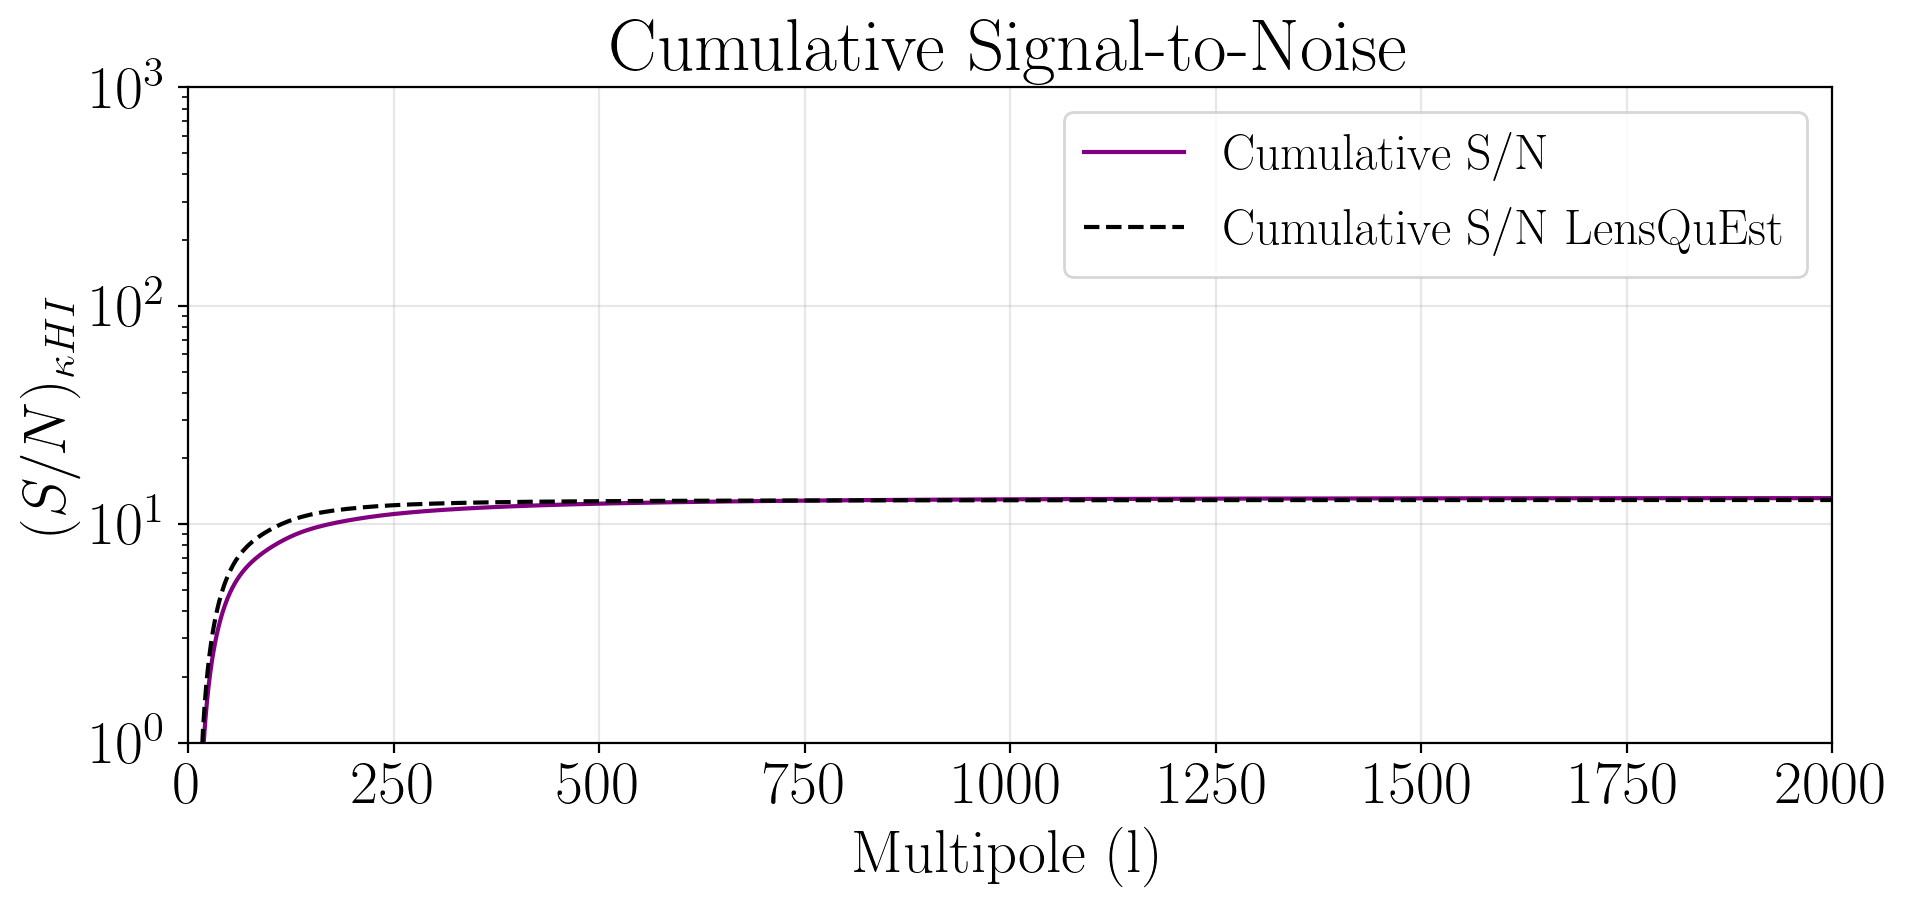

In [68]:
#plot snr
#  Calculate Cumulative SNR (Equation 16 giannantonio 2015) ---
cumulative_snr = np.zeros_like(ls, dtype=float)
snr_squared_sum = 0.0

snr_l_sq = f_sky*(2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k + N_kk) * (cl_hihi + N_hihi))

cumulative_snr = np.sqrt(np.cumsum(snr_l_sq[2:]))

snr_l_sq_th = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (cl_k_k) * (cl_hihi))


cumulative_snr_th = np.sqrt(np.cumsum(snr_l_sq_th[2:]))


cumulative_snrq = np.zeros_like(ls, dtype=float)
snr_squared_sumq = 0.0

snr_l_sqq = f_sky*(2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (Clq + Nq) * (cl_hihi + N_hihi))

cumulative_snrq = np.sqrt(np.cumsum(snr_l_sqq[2:]))

snr_l_sq_thq = (2*ls+1)*(cl_k_hi**2) / ((cl_k_hi**2) + (Clq) * (cl_hihi))


cumulative_snr_th = np.sqrt(np.cumsum(snr_l_sq_thq[2:]))





fig, (ax3) = plt.subplots(1, 1, figsize=(10, 5), sharex=True)
# Bottom: Cumulative SNR
ax3.plot(ls[2:], cumulative_snr, color='purple', label='Cumulative S/N')
ax3.plot(ls[2:], cumulative_snrq, color='black', linestyle='--', label='Cumulative S/N LensQuEst')
#ax3.plot(ls[2:], cumulative_snr_th, color='blue', label='Cumulative S/N Th')

ax3.set_yscale('log')
ax3.set_ylabel(r'$(S/N)_{\kappa HI}$')
ax3.set_xlabel('Multipole (l)')
ax3.set_title('Cumulative Signal-to-Noise')
ax3.set_xlim(0, 2000)
ax3.set_ylim(1, 1000) # Adjust based on expected DES-SV SNR (~5-8)
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
#CROSS POWER SPECTRUM IS STILL FROM CAMB ALONE!!!!!!

In [ ]:
# Tell CAMB to compute the matter power spectrum
M_pars.set_matter_power(redshifts=[0.], kmax=10.0)
results = camb.get_results(M_pars)

# Get the linear matter power spectrum at z=0
k, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10, npoints=2000)

# Save it directly into the Planck15 folder
#np.savetxt("./input/universe_Planck15/camb/matterpower_z0_lin_MeerKlass.dat", np.column_stack((k, pk[0])))

In [ ]:
f_sky

# quicklens